### Ring Attractor Validation for Circuit Discovery

#### Imports

In [1]:
# Cell 1: Setup & Imports
"""
Ring Attractor Validation for Circuit Discovery Methods
========================================================
Ground truth validation of windowed causal interventions + time-resolved linearization
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

In [4]:
# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9

print("✓ Imports successful")
print("✓ Seeds set for reproducibility")
print("✓ Plotting style configured")

✓ Imports successful
✓ Seeds set for reproducibility
✓ Plotting style configured


#### Ring Attractor Architecture

In [5]:
# Cell 2: Ring Attractor Class - Architecture
"""
Ring Attractor with Dale's Law
- Excitatory neurons: Nearest-neighbor coupling (positive weights)
- Inhibitory neurons: Global inhibition (negative weights)
- Nonlinearity: h = ReLU(tanh(a))
- Readout: Position classification (K discrete positions)
"""

class RingAttractor(nn.Module):
    def __init__(self,
                 N_total=24,           # Total neurons
                 frac_exc=0.8,         # Fraction excitatory (0.8 → 80/20 E/I)
                 W_exc=0.8,            # Nearest-neighbor excitatory strength
                 W_inh=0.3,            # Global inhibitory strength
                 K_positions=4,        # Number of position classes for readout
                 device='cpu'):
        super(RingAttractor, self).__init__()

        self.N = N_total
        self.K = K_positions
        self.device = device

        # E/I partitioning
        self.N_exc = int(N_total * frac_exc)
        self.N_inh = N_total - self.N_exc
        print(f"Ring Attractor: {self.N} neurons ({self.N_exc} E, {self.N_inh} I)")

        # Neuron type labels: +1 for E, -1 for I
        self.neuron_types = np.array([1]*self.N_exc + [-1]*self.N_inh)

        # Indices for each population
        self.exc_idx = np.arange(self.N_exc)
        self.inh_idx = np.arange(self.N_exc, self.N)

        # Initialize recurrent weights (deterministic, hand-designed)
        self.W_hh = self._initialize_ring_weights(W_exc, W_inh)

        # Initialize readout weights (analytical design)
        self.W_out = self._initialize_readout()
        self.b_out = nn.Parameter(torch.zeros(self.K), requires_grad=False)

        # Store for later use
        self.W_exc_strength = W_exc
        self.W_inh_strength = W_inh

        print(f"✓ Recurrent weights initialized (Dale's law enforced)")
        print(f"✓ Readout layer: {self.N} → {self.K} position classes")

    def _initialize_ring_weights(self, W_exc, W_inh):
        """
        Hand-designed connectivity:
        - E neurons (0 to N_exc-1): Nearest-neighbor excitation on ring
        - I neurons (N_exc to N-1): Evenly spaced, global inhibition
        """
        W = np.zeros((self.N, self.N), dtype=np.float32)

        # Excitatory: nearest-neighbor coupling (circular)
        for i in self.exc_idx:
            # Connect to left and right neighbors (with wraparound)
            left = (i - 1) % self.N_exc
            right = (i + 1) % self.N_exc
            W[i, left] = W_exc
            W[i, right] = W_exc

        # Inhibitory: global uniform inhibition from I neurons
        # Distribute I neurons evenly around the ring
        inh_spacing = self.N // self.N_inh
        for idx, i in enumerate(self.inh_idx):
            # Each I neuron inhibits all E neurons
            W[self.exc_idx, i] = -W_inh
            # I neurons also receive excitation from nearby E neurons
            nearby_e = (idx * inh_spacing) % self.N_exc
            for offset in [-1, 0, 1]:
                e_idx = (nearby_e + offset) % self.N_exc
                W[i, e_idx] = W_exc * 0.5  # Weaker input to I neurons

        # Convert to parameter (non-trainable)
        W_tensor = torch.from_numpy(W).float().to(self.device)
        self.register_buffer('W_hh_buffer', W_tensor)

        return W_tensor

    def _initialize_readout(self):
        """
        Analytical readout: Each of K position classes reads from ~N/K local neurons
        Position class k is centered at neuron index (k * N_exc / K)
        """
        W_out = np.zeros((self.K, self.N), dtype=np.float32)
        neurons_per_class = self.N_exc // self.K

        for k in range(self.K):
            # Center of this position class
            center = int((k * self.N_exc) / self.K)
            # Read from neurons in [center - radius, center + radius]
            radius = neurons_per_class // 2
            for offset in range(-radius, radius + 1):
                idx = (center + offset) % self.N_exc
                # Gaussian-like weighting (strongest at center)
                weight = np.exp(-0.5 * (offset / (radius + 1))**2)
                W_out[k, idx] = weight

        # Normalize rows to sum to 1
        W_out = W_out / (W_out.sum(axis=1, keepdims=True) + 1e-8)

        W_tensor = torch.from_numpy(W_out).float().to(self.device)
        self.register_buffer('W_out_buffer', W_tensor)

        return W_tensor

    def visualize_structure(self):
        """Visualize ring connectivity and neuron types"""
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # Panel A: Recurrent weight matrix
        ax = axes[0]
        im = ax.imshow(self.W_hh.cpu().numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_title('Recurrent Weights (W_hh)')
        ax.set_xlabel('Presynaptic neuron')
        ax.set_ylabel('Postsynaptic neuron')
        # Add lines separating E and I
        ax.axhline(self.N_exc - 0.5, color='k', linewidth=2, linestyle='--')
        ax.axvline(self.N_exc - 0.5, color='k', linewidth=2, linestyle='--')
        ax.text(self.N_exc/2, -2, 'E', ha='center', fontsize=12, weight='bold')
        ax.text(self.N_exc + self.N_inh/2, -2, 'I', ha='center', fontsize=12, weight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Panel B: Readout weights
        ax = axes[1]
        im = ax.imshow(self.W_out.cpu().numpy(), cmap='viridis', aspect='auto')
        ax.set_title('Readout Weights (W_out)')
        ax.set_xlabel('Neuron index')
        ax.set_ylabel('Position class')
        ax.set_yticks(range(self.K))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Panel C: Ring schematic (circular layout)
        ax = axes[2]
        theta = np.linspace(0, 2*np.pi, self.N, endpoint=False)
        x = np.cos(theta)
        y = np.sin(theta)

        # Plot neurons colored by type
        colors = ['red' if t > 0 else 'blue' for t in self.neuron_types]
        ax.scatter(x, y, c=colors, s=200, edgecolors='k', linewidths=1.5, zorder=3)

        # Annotate neuron indices
        for i in range(self.N):
            ax.text(x[i]*1.15, y[i]*1.15, str(i), ha='center', va='center', fontsize=8)

        # Draw some example connections (just a few for clarity)
        for i in range(0, self.N_exc, 3):  # Sample every 3rd E neuron
            left = (i - 1) % self.N_exc
            right = (i + 1) % self.N_exc
            ax.plot([x[i], x[left]], [y[i], y[left]], 'r-', alpha=0.3, linewidth=1)
            ax.plot([x[i], x[right]], [y[i], y[right]], 'r-', alpha=0.3, linewidth=1)

        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title('Ring Structure\n(Red=E, Blue=I)')

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='red', label='Excitatory'),
                          Patch(facecolor='blue', label='Inhibitory')]
        ax.legend(handles=legend_elements, loc='upper right')

        plt.tight_layout()
        plt.show()

        # Print statistics
        print(f"\n=== Ring Attractor Statistics ===")
        print(f"Total neurons: {self.N} ({self.N_exc} E, {self.N_inh} I)")
        print(f"E→E connections: {(self.W_hh[self.exc_idx][:, self.exc_idx] != 0).sum().item():.0f}")
        print(f"I→E connections: {(self.W_hh[self.exc_idx][:, self.inh_idx] != 0).sum().item():.0f}")
        print(f"E→I connections: {(self.W_hh[self.inh_idx][:, self.exc_idx] != 0).sum().item():.0f}")
        print(f"Position classes: {self.K}")
        print(f"Neurons per class: ~{self.N_exc // self.K}")

Ring Attractor: 24 neurons (19 E, 5 I)
✓ Recurrent weights initialized (Dale's law enforced)
✓ Readout layer: 24 → 4 position classes


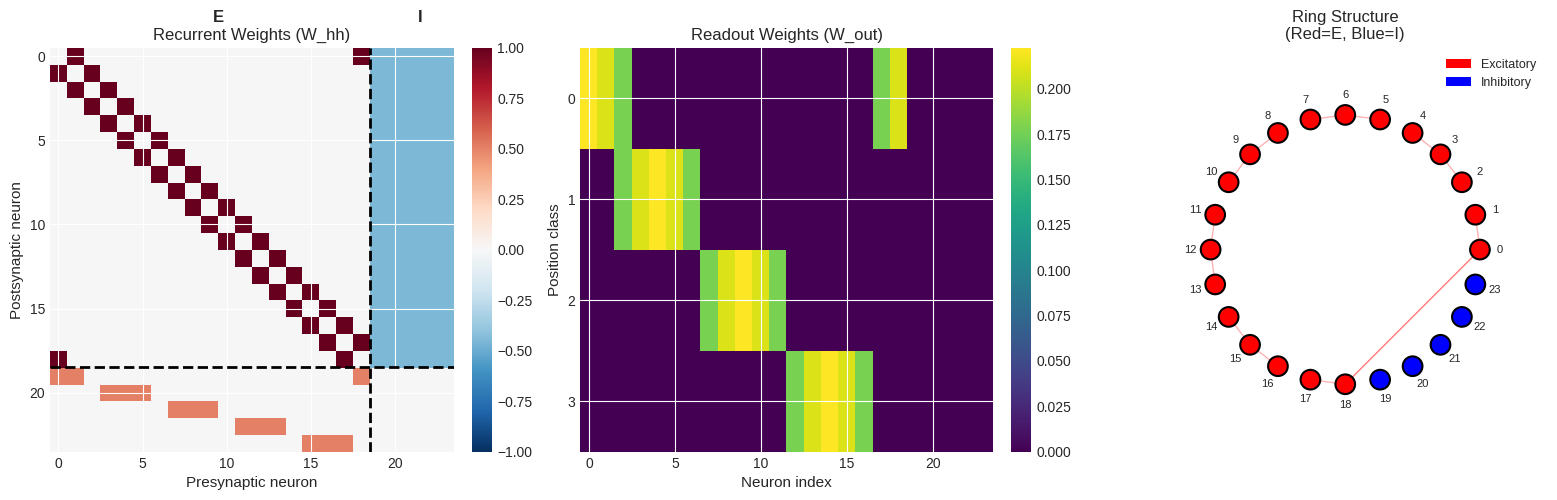


=== Ring Attractor Statistics ===
Total neurons: 24 (19 E, 5 I)
E→E connections: 38
I→E connections: 95
E→I connections: 15
Position classes: 4
Neurons per class: ~4


In [6]:
# Instantiate and visualize
ring = RingAttractor(N_total=24, frac_exc=0.8, W_exc=1., W_inh=0.45, K_positions=4, device=device)
ring.visualize_structure()

#### Ring Attractor Dynamics

In [7]:
# Cell 3: Ring Attractor Class - Dynamics
"""
Forward dynamics with tanh-then-ReLU nonlinearity:
  a[t] = W_hh @ h[t-1] + W_ih @ x[t] + b_h
  u[t] = tanh(a[t])
  h[t] = ReLU(u[t])
  z[t] = W_out @ h[t] + b_out

Returns full trajectory: hidden states, logits, predicted classes
"""

def forward_dynamics(self, inputs, h0=None, return_intermediates=False):
    """
    Forward pass through ring attractor dynamics.

    Args:
        inputs: (batch_size, n_steps, input_dim) or (batch_size, n_steps)
        h0: Initial hidden state (batch_size, N). If None, initialized to zeros.
        return_intermediates: If True, return pre-activations and tanh outputs

    Returns:
        dict with keys:
            'hidden': (batch_size, n_steps, N) - ReLU(tanh(a))
            'logits': (batch_size, n_steps, K) - position class logits
            'classes': (batch_size, n_steps) - argmax class predictions
            'margin': (batch_size, n_steps) - decision margins
            (optional) 'pre_act': (batch_size, n_steps, N) - a[t]
            (optional) 'tanh_act': (batch_size, n_steps, N) - tanh(a[t])
    """
    # Handle input shape
    if inputs.dim() == 2:  # (batch, time) → add feature dim
        inputs = inputs.unsqueeze(-1)

    batch_size, n_steps, input_dim = inputs.shape
    inputs = inputs.to(self.device)

    # Initialize hidden state
    if h0 is None:
        h = torch.zeros(batch_size, self.N, device=self.device)
    else:
        h = h0.to(self.device)

    # Input projection (if input_dim > 0, we need W_ih; for now assume inputs are direct injections)
    if not hasattr(self, 'W_ih'):
        # For simplicity: inputs directly added to first few neurons (bump initialization)
        # We'll handle this more elegantly in the input generation cell
        W_ih = torch.zeros(self.N, input_dim, device=self.device)
        # Map input to first input_dim neurons
        for i in range(min(input_dim, self.N)):
            W_ih[i, i] = 1.0
        self.register_buffer('W_ih', W_ih)

    # Storage
    hidden_states = []
    logits_seq = []
    classes_seq = []
    margins_seq = []

    if return_intermediates:
        pre_act_seq = []
        tanh_act_seq = []

    # Run dynamics
    for t in range(n_steps):
        x_t = inputs[:, t, :]  # (batch, input_dim)

        # Pre-activation: a = W_hh @ h + W_ih @ x
        a = torch.matmul(h, self.W_hh.t()) + torch.matmul(x_t, self.W_ih.t())

        # Nonlinearity: h = ReLU(tanh(a))
        u = torch.tanh(a)
        h = torch.clamp(u, min=0.0)  # ReLU

        # Readout
        z = torch.matmul(h, self.W_out.t()) + self.b_out  # (batch, K)

        # Predictions
        pred_class = torch.argmax(z, dim=-1)  # (batch,)

        # Decision margin (for causal interventions)
        margin = self._compute_margin(z, pred_class)

        # Store
        hidden_states.append(h.detach().cpu())
        logits_seq.append(z.detach().cpu())
        classes_seq.append(pred_class.detach().cpu())
        margins_seq.append(margin.detach().cpu())

        if return_intermediates:
            pre_act_seq.append(a.detach().cpu())
            tanh_act_seq.append(u.detach().cpu())

    # Stack into tensors
    output = {
        'hidden': torch.stack(hidden_states, dim=1),      # (batch, time, N)
        'logits': torch.stack(logits_seq, dim=1),         # (batch, time, K)
        'classes': torch.stack(classes_seq, dim=1),       # (batch, time)
        'margin': torch.stack(margins_seq, dim=1),        # (batch, time)
    }

    if return_intermediates:
        output['pre_act'] = torch.stack(pre_act_seq, dim=1)
        output['tanh_act'] = torch.stack(tanh_act_seq, dim=1)

    return output

In [8]:
def _compute_margin(self, logits, pred_classes):
    """
    Compute decision margin: z[predicted] - max(z[others])

    Args:
        logits: (batch, K)
        pred_classes: (batch,) - indices of predicted classes

    Returns:
        margin: (batch,)
    """
    batch_size = logits.shape[0]

    # Gather predicted class logits
    pred_logits = logits.gather(1, pred_classes.unsqueeze(1)).squeeze(1)  # (batch,)

    # Mask out predicted class, find max of others
    mask = torch.ones_like(logits, dtype=torch.bool)
    mask.scatter_(1, pred_classes.unsqueeze(1), False)

    other_max = logits.masked_fill(~mask, -1e9).max(dim=1).values  # (batch,)

    margin = pred_logits - other_max
    return margin

In [9]:
# Add methods to the class
RingAttractor.forward = forward_dynamics
RingAttractor._compute_margin = _compute_margin

print("✓ Forward dynamics implemented")
print("✓ Margin computation added")

# Quick test: Random input trajectory
print("\n=== Testing Forward Pass ===")
test_batch = 4
test_steps = 10
test_input = torch.randn(test_batch, test_steps, 1) * 0.1  # Small random inputs

output = ring.forward(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Hidden states shape: {output['hidden'].shape}")
print(f"Logits shape: {output['logits'].shape}")
print(f"Predicted classes shape: {output['classes'].shape}")
print(f"Margin shape: {output['margin'].shape}")

# Check a single trajectory
print(f"\nExample trajectory (first sample):")
print(f"  Predicted classes: {output['classes'][0].numpy()}")
print(f"  Margins (first 5 steps): {output['margin'][0, :5].numpy()}")
print(f"  Max hidden activity per step: {output['hidden'][0].max(dim=-1).values[:5].numpy()}")

✓ Forward dynamics implemented
✓ Margin computation added

=== Testing Forward Pass ===
Input shape: torch.Size([4, 10, 1])
Hidden states shape: torch.Size([4, 10, 24])
Logits shape: torch.Size([4, 10, 4])
Predicted classes shape: torch.Size([4, 10])
Margin shape: torch.Size([4, 10])

Example trajectory (first sample):
  Predicted classes: [0 0 0 0 0 0 0 0 0 0]
  Margins (first 5 steps): [0.04236031 0.11204568 0.15874656 0.16418487 0.18280335]
  Max hidden activity per step: [0.19034155 0.18807569 0.39989597 0.40450808 0.6116092 ]


#### Test Ring Attractor Functionality

In [10]:
# Cell 4: Test Ring Attractor Functionality
"""
Verify the ring attractor behaves as expected:
1. Localized input creates a bump at the correct position
2. Bump persists without additional input (memory)
3. Readout correctly classifies bump position
"""

# FIX: Remove old W_ih from Cell 3's test (it was for 1D inputs)
if hasattr(ring, 'W_ih'):
    delattr(ring, 'W_ih')

# Now create proper W_ih for 24D inputs (identity mapping)
W_ih = torch.eye(ring.N, device=ring.device)  # (24, 24) identity matrix
ring.register_buffer('W_ih', W_ih)
print("✓ Input weights reset for N-dimensional inputs")

def create_bump_input(ring, target_neurons, strength=2.0, duration=3, total_steps=15):
    """
    Create input that injects current to specific neurons for a few timesteps.

    Args:
        ring: RingAttractor instance
        target_neurons: List of neuron indices to stimulate
        strength: Injection amplitude
        duration: How many timesteps to inject
        total_steps: Total sequence length

    Returns:
        inputs: (1, total_steps, N) tensor
        ground_truth_class: Expected position class
    """
    inputs = torch.zeros(1, total_steps, ring.N)

    # Inject to target neurons for first 'duration' steps
    for t in range(duration):
        for neuron_idx in target_neurons:
            inputs[0, t, neuron_idx] = strength

    # Determine ground truth position class
    # Find center of target neurons, map to position class
    center_neuron = int(np.mean(target_neurons))
    # Each class corresponds to ~N_exc/K neurons
    neurons_per_class = ring.N_exc / ring.K
    ground_truth_class = int(center_neuron / neurons_per_class)

    return inputs, ground_truth_class

✓ Input weights reset for N-dimensional inputs


In [11]:
# Test 1: Create bump at position 0 (neurons 0-2)
print("\n=== Test 1: Bump at Position 0 (neurons 0-2) ===")
target_neurons_0 = [0, 1, 2]
inputs_0, gt_class_0 = create_bump_input(ring, target_neurons_0, strength=2.0, duration=3, total_steps=15)

output_0 = ring.forward(inputs_0)
predicted_classes_0 = output_0['classes'][0].numpy()

print(f"Ground truth class: {gt_class_0}")
print(f"Predicted classes: {predicted_classes_0}")
print(f"Classification accuracy: {(predicted_classes_0 == gt_class_0).mean()*100:.1f}%")
print(f"Average margin: {output_0['margin'][0].mean():.3f}")

# Test 2: Create bump at position 4 (neurons 9-11, opposite side of ring)
print("\n=== Test 2: Bump at Position 4 (neurons 9-11) ===")
target_neurons_4 = [9, 10, 11]
inputs_4, gt_class_4 = create_bump_input(ring, target_neurons_4, strength=2.0, duration=3, total_steps=15)

output_4 = ring.forward(inputs_4)
predicted_classes_4 = output_4['classes'][0].numpy()

print(f"Ground truth class: {gt_class_4}")
print(f"Predicted classes: {predicted_classes_4}")
print(f"Classification accuracy: {(predicted_classes_4 == gt_class_4).mean()*100:.1f}%")
print(f"Average margin: {output_4['margin'][0].mean():.3f}")


=== Test 1: Bump at Position 0 (neurons 0-2) ===
Ground truth class: 0
Predicted classes: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Classification accuracy: 100.0%
Average margin: 0.240

=== Test 2: Bump at Position 4 (neurons 9-11) ===
Ground truth class: 2
Predicted classes: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Classification accuracy: 100.0%
Average margin: 0.340


In [12]:
# Visualize one trajectory
def plot_bump_trajectory(ring, inputs, output, ground_truth_class, title="Bump Trajectory"):
    """Visualize hidden states and predictions over time"""
    hidden = output['hidden'][0].numpy()  # (time, N)
    classes = output['classes'][0].numpy()  # (time,)
    margin = output['margin'][0].numpy()   # (time,)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Panel A: Hidden state heatmap
    ax = axes[0]
    im = ax.imshow(hidden.T, aspect='auto', cmap='hot', interpolation='nearest')
    ax.set_ylabel('Neuron index')
    ax.set_xlabel('Time step')
    ax.set_title(f'{title}: Hidden State Activity')
    ax.axhline(ring.N_exc - 0.5, color='cyan', linewidth=2, linestyle='--', label='E/I boundary')
    plt.colorbar(im, ax=ax, label='Activity')
    ax.legend(loc='upper right')

    # Panel B: Predicted vs ground truth classes
    ax = axes[1]
    ax.plot(classes, 'o-', label='Predicted class', markersize=8, linewidth=2)
    ax.axhline(ground_truth_class, color='red', linestyle='--', linewidth=2, label=f'Ground truth (class {ground_truth_class})')
    ax.set_ylabel('Position class')
    ax.set_xlabel('Time step')
    ax.set_title('Position Classification')
    ax.set_ylim(-0.5, ring.K - 0.5)
    ax.legend()
    ax.grid(alpha=0.3)

    # Panel C: Decision margin
    ax = axes[2]
    ax.plot(margin, 'o-', color='green', markersize=6, linewidth=2)
    ax.axhline(0, color='k', linestyle='-', linewidth=1)
    ax.set_ylabel('Margin')
    ax.set_xlabel('Time step')
    ax.set_title('Decision Confidence (margin)')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


=== Visualization: Position 0 Trajectory ===


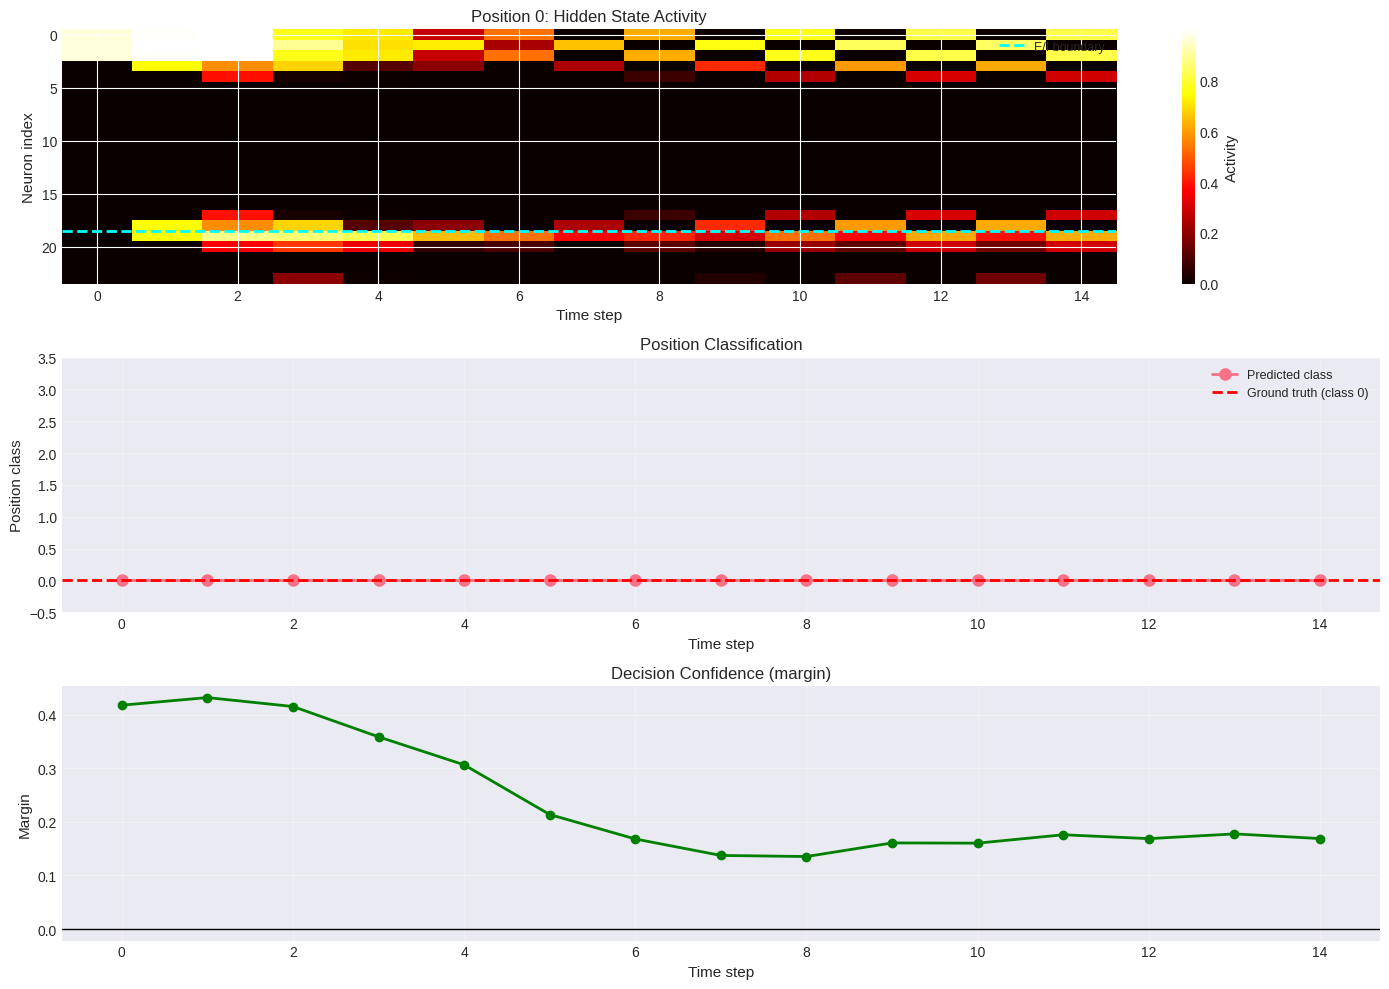


=== Visualization: Position 4 Trajectory ===


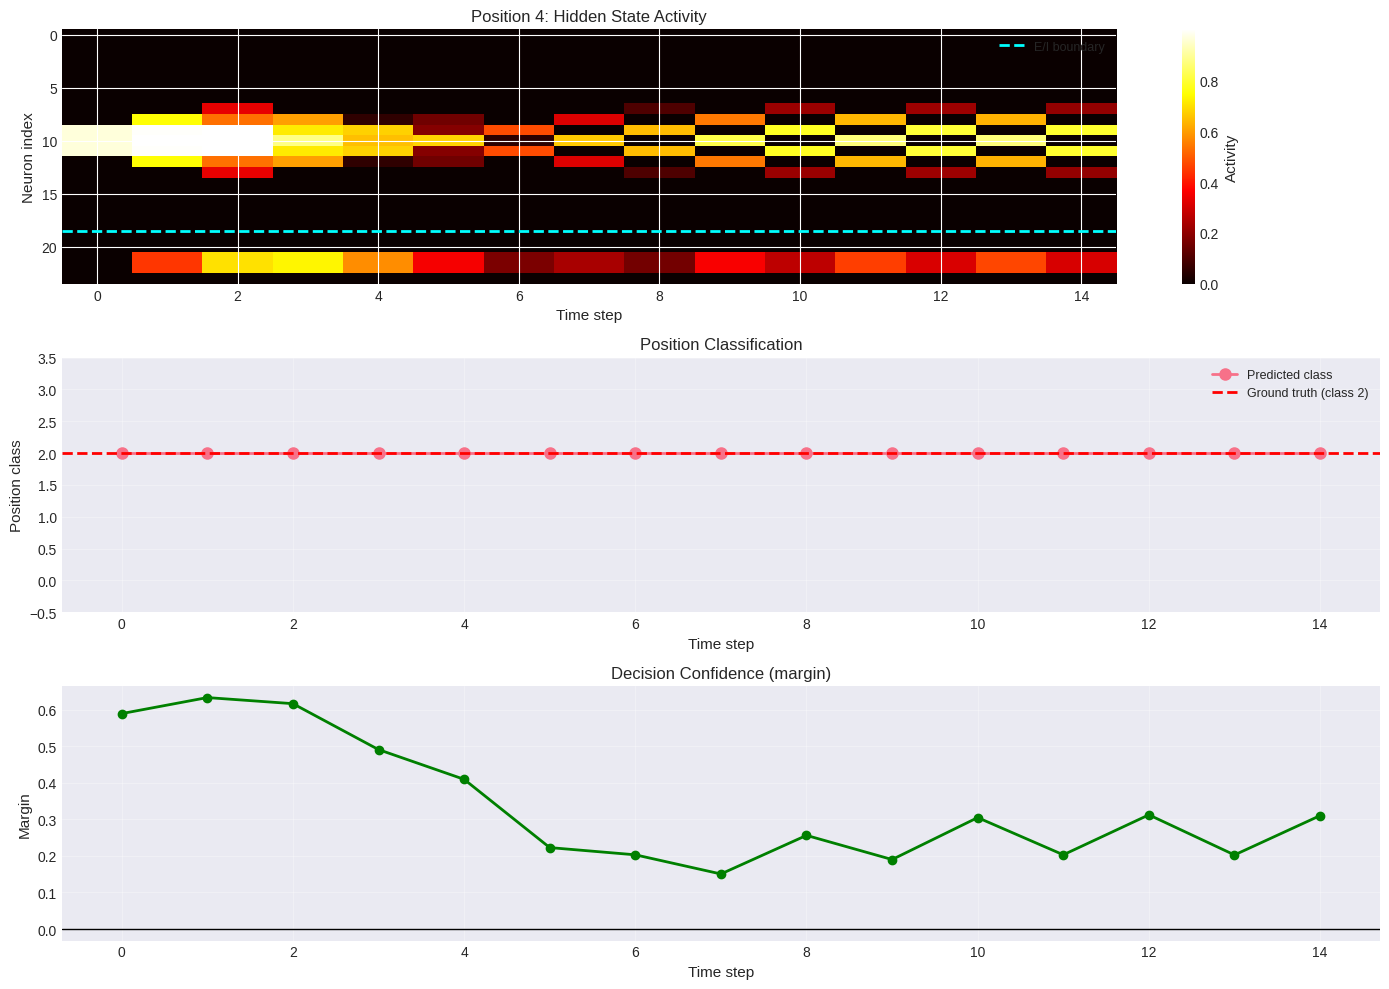


✓ Ring attractor functionality test complete


In [13]:
print("\n=== Visualization: Position 0 Trajectory ===")
plot_bump_trajectory(ring, inputs_0, output_0, gt_class_0, title="Position 0")

print("\n=== Visualization: Position 4 Trajectory ===")
plot_bump_trajectory(ring, inputs_4, output_4, gt_class_4, title="Position 4")

print("\n✓ Ring attractor functionality test complete")

#### Tune Ring Attractor Parameters

In [14]:
# # Cell 5: Tune Ring Attractor Parameters
# """
# Increase inhibition strength to sharpen the bump
# """

# # Create new ring with stronger inhibition
# ring_v2 = RingAttractor(
#     N_total=24,
#     frac_exc=0.8,
#     W_exc=1.,
#     W_inh=0.45,
#     K_positions=4,
#     device=device
# )

# # Reset input weights
# if hasattr(ring_v2, 'W_ih'):
#     delattr(ring_v2, 'W_ih')
# W_ih = torch.eye(ring_v2.N, device=ring_v2.device)
# ring_v2.register_buffer('W_ih', W_ih)

# # Re-test Position 0
# print("\n=== Test Position 0 with Stronger Inhibition ===")
# inputs_0_v2, gt_class_0_v2 = create_bump_input(ring_v2, [0, 1, 2], strength=2.0, duration=3, total_steps=15)
# output_0_v2 = ring_v2.forward(inputs_0_v2)
# predicted_classes_0_v2 = output_0_v2['classes'][0].numpy()

# print(f"Ground truth class: {gt_class_0_v2}")
# print(f"Predicted classes: {predicted_classes_0_v2}")
# print(f"Classification accuracy: {(predicted_classes_0_v2 == gt_class_0_v2).mean()*100:.1f}%")
# print(f"Average margin: {output_0_v2['margin'][0].mean():.6f}")  # More decimal places

# # Re-test Position 4
# print("\n=== Test Position 4 with Stronger Inhibition ===")
# inputs_4_v2, gt_class_4_v2 = create_bump_input(ring_v2, [9, 10, 11], strength=2.0, duration=3, total_steps=15)
# output_4_v2 = ring_v2.forward(inputs_4_v2)
# predicted_classes_4_v2 = output_4_v2['classes'][0].numpy()

# print(f"Ground truth class: {gt_class_4_v2}")
# print(f"Predicted classes: {predicted_classes_4_v2}")
# print(f"Classification accuracy: {(predicted_classes_4_v2 == gt_class_4_v2).mean()*100:.1f}%")
# print(f"Average margin: {output_4_v2['margin'][0].mean():.6f}")

# # Visualize
# plot_bump_trajectory(ring_v2, inputs_0_v2, output_0_v2, gt_class_0_v2, title="Position 0")
# plot_bump_trajectory(ring_v2, inputs_4_v2, output_4_v2, gt_class_4_v2, title="Position 4")

#### Validate Ring Attractor (Additional Test Cases)

In [15]:
# Cell 6: Generate Test Trajectories & Ground Truth
"""
Create diverse test cases for circuit discovery validation:
1. Static bumps at different positions
2. Traveling bump (gradual drift)
3. Jumping bump (discrete position change)

Each trajectory includes ground truth: which neurons should be identified as important
"""

class TrajectoryGenerator:
    """Generate ring attractor trajectories with known ground truth circuits"""

    def __init__(self, ring):
        self.ring = ring
        self.N = ring.N
        self.N_exc = ring.N_exc
        self.K = ring.K

    def _position_to_neurons(self, position_class, radius=1):
        """
        Map position class to neuron indices.

        Args:
            position_class: int in [0, K-1]
            radius: how many neighbors on each side

        Returns:
            list of neuron indices
        """
        # Center neuron for this position class
        neurons_per_class = self.N_exc / self.K
        center = int((position_class + 0.5) * neurons_per_class)

        # Get neighbors within radius (circular)
        neurons = []
        for offset in range(-radius, radius + 1):
            idx = (center + offset) % self.N_exc
            neurons.append(idx)

        return sorted(set(neurons))

    def static_bump(self, position_class, duration=20, maintenance_strength=0.5):
        """
        Static bump: Initialize at position, maintain with weak input.

        Ground truth: Neurons at position_class should be identified throughout.
        """
        inputs = torch.zeros(1, duration, self.N)

        # Strong initialization (first 3 steps)
        target_neurons = self._position_to_neurons(position_class, radius=1)
        for t in range(3):
            for n in target_neurons:
                inputs[0, t, n] = 2.0

        # Weak maintenance (rest of trajectory)
        for t in range(3, duration):
            for n in target_neurons:
                inputs[0, t, n] = maintenance_strength

        # Ground truth: same neurons important at all times
        ground_truth = {
            'position_class': position_class,
            'important_neurons': {t: target_neurons for t in range(duration)},
            'type': 'static'
        }

        return inputs, ground_truth

    def traveling_bump(self, start_class, end_class, duration=25, speed='slow'):
        """
        Traveling bump: Gradually shift input to make bump drift.

        Ground truth: Important neurons shift over time as bump moves.
        """
        inputs = torch.zeros(1, duration, self.N)

        # Determine shift schedule
        if speed == 'slow':
            shift_start = 5
            shift_end = 20
        else:  # fast
            shift_start = 3
            shift_end = 12

        ground_truth_neurons = {}

        for t in range(duration):
            if t < shift_start:
                # Before shift: maintain start position
                pos = start_class
            elif t > shift_end:
                # After shift: maintain end position
                pos = end_class
            else:
                # During shift: interpolate
                progress = (t - shift_start) / (shift_end - shift_start)
                pos_float = start_class + progress * (end_class - start_class)
                pos = int(round(pos_float))

            # Input to current position
            target_neurons = self._position_to_neurons(pos, radius=1)
            for n in target_neurons:
                if t < 3:
                    inputs[0, t, n] = 2.0  # Strong init
                else:
                    inputs[0, t, n] = 0.5  # Maintenance

            ground_truth_neurons[t] = target_neurons

        ground_truth = {
            'start_class': start_class,
            'end_class': end_class,
            'important_neurons': ground_truth_neurons,
            'type': 'traveling',
            'shift_window': (shift_start, shift_end)
        }

        return inputs, ground_truth

    def jumping_bump(self, class_sequence, duration_per_class=8):
        """
        Jumping bump: Discrete position changes.

        Args:
            class_sequence: list of position classes, e.g., [0, 2, 1]

        Ground truth: Important neurons change abruptly at transitions.
        """
        total_duration = len(class_sequence) * duration_per_class
        inputs = torch.zeros(1, total_duration, self.N)

        ground_truth_neurons = {}
        transition_times = []

        for i, pos_class in enumerate(class_sequence):
            start_t = i * duration_per_class
            end_t = (i + 1) * duration_per_class

            if i > 0:
                transition_times.append(start_t)

            target_neurons = self._position_to_neurons(pos_class, radius=1)

            for t in range(start_t, end_t):
                # Strong pulse at transition, then maintenance
                strength = 2.0 if (t - start_t) < 3 else 0.5
                for n in target_neurons:
                    inputs[0, t, n] = strength

                ground_truth_neurons[t] = target_neurons

        ground_truth = {
            'class_sequence': class_sequence,
            'important_neurons': ground_truth_neurons,
            'type': 'jumping',
            'transition_times': transition_times,
            'duration_per_class': duration_per_class
        }

        return inputs, ground_truth

In [16]:
ring_v3 = RingAttractor(N_total=24, frac_exc=0.8, W_exc=1., W_inh=0.45, K_positions=4, device=device)

Ring Attractor: 24 neurons (19 E, 5 I)
✓ Recurrent weights initialized (Dale's law enforced)
✓ Readout layer: 24 → 4 position classes


In [17]:
# Instantiate generator
gen = TrajectoryGenerator(ring_v3)

# Generate test trajectories
trajectories = {}

print("=== Generating Test Trajectories ===\n")

=== Generating Test Trajectories ===



In [18]:
# Cell 6 (REVISED): Generate Test Trajectories & Ground Truth
"""
Create diverse test cases - FIX: Align input targeting with readout receptive fields
"""

class TrajectoryGenerator:
    """Generate ring attractor trajectories with known ground truth circuits"""

    def __init__(self, ring):
        self.ring = ring
        self.N = ring.N
        self.N_exc = ring.N_exc
        self.K = ring.K

    def _position_to_neurons(self, position_class, radius=2):
        """
        Map position class to neuron indices.
        CRITICAL: Must match the readout layer's receptive field calculation!

        Args:
            position_class: int in [0, K-1]
            radius: how many neighbors on each side (default 2 to match readout)

        Returns:
            list of neuron indices
        """
        # Use SAME calculation as _initialize_readout in RingAttractor
        center = int((position_class * self.N_exc) / self.K)

        # Get neighbors within radius (circular)
        neurons = []
        for offset in range(-radius, radius + 1):
            idx = (center + offset) % self.N_exc
            neurons.append(idx)

        return sorted(set(neurons))

    def static_bump(self, position_class, duration=20, maintenance_strength=0.5):
        """
        Static bump: Initialize at position, maintain with weak input.

        Ground truth: Neurons at position_class should be identified throughout.
        """
        inputs = torch.zeros(1, duration, self.N)

        # Strong initialization (first 3 steps)
        target_neurons = self._position_to_neurons(position_class, radius=2)
        for t in range(3):
            for n in target_neurons:
                inputs[0, t, n] = 2.0

        # Weak maintenance (rest of trajectory)
        for t in range(3, duration):
            for n in target_neurons:
                inputs[0, t, n] = maintenance_strength

        # Ground truth: same neurons important at all times
        ground_truth = {
            'position_class': position_class,
            'important_neurons': {t: target_neurons for t in range(duration)},
            'type': 'static'
        }

        return inputs, ground_truth

    def traveling_bump(self, start_class, end_class, duration=25, speed='slow'):
        """
        Traveling bump: Gradually shift input to make bump drift.

        Ground truth: Important neurons shift over time as bump moves.
        """
        inputs = torch.zeros(1, duration, self.N)

        # Determine shift schedule
        if speed == 'slow':
            shift_start = 5
            shift_end = 20
        else:  # fast
            shift_start = 3
            shift_end = 12

        ground_truth_neurons = {}

        for t in range(duration):
            if t < shift_start:
                # Before shift: maintain start position
                pos = start_class
            elif t > shift_end:
                # After shift: maintain end position
                pos = end_class
            else:
                # During shift: interpolate
                progress = (t - shift_start) / (shift_end - shift_start)
                pos_float = start_class + progress * (end_class - start_class)
                pos = int(round(pos_float))

            # Input to current position
            target_neurons = self._position_to_neurons(pos, radius=2)
            for n in target_neurons:
                if t < 3:
                    inputs[0, t, n] = 2.0  # Strong init
                else:
                    inputs[0, t, n] = 0.5  # Maintenance

            ground_truth_neurons[t] = target_neurons

        ground_truth = {
            'start_class': start_class,
            'end_class': end_class,
            'important_neurons': ground_truth_neurons,
            'type': 'traveling',
            'shift_window': (shift_start, shift_end)
        }

        return inputs, ground_truth

    def jumping_bump(self, class_sequence, duration_per_class=8):
        """
        Jumping bump: Discrete position changes.

        Args:
            class_sequence: list of position classes, e.g., [0, 2, 1]

        Ground truth: Important neurons change abruptly at transitions.
        """
        total_duration = len(class_sequence) * duration_per_class
        inputs = torch.zeros(1, total_duration, self.N)

        ground_truth_neurons = {}
        transition_times = []

        for i, pos_class in enumerate(class_sequence):
            start_t = i * duration_per_class
            end_t = (i + 1) * duration_per_class

            if i > 0:
                transition_times.append(start_t)

            target_neurons = self._position_to_neurons(pos_class, radius=2)

            for t in range(start_t, end_t):
                # Strong pulse at transition, then maintenance
                strength = 2.0 if (t - start_t) < 3 else 0.5
                for n in target_neurons:
                    inputs[0, t, n] = strength

                ground_truth_neurons[t] = target_neurons

        ground_truth = {
            'class_sequence': class_sequence,
            'important_neurons': ground_truth_neurons,
            'type': 'jumping',
            'transition_times': transition_times,
            'duration_per_class': duration_per_class
        }

        return inputs, ground_truth

# Instantiate generator
gen = TrajectoryGenerator(ring_v3)

# Generate test trajectories
trajectories = {}

print("=== Generating Test Trajectories (FIXED) ===\n")

# Verify neuron targeting is correct
print("Position class → target neurons (should match readout receptive fields):")
for pos in range(ring_v3.K):
    neurons = gen._position_to_neurons(pos, radius=2)
    print(f"  Class {pos}: neurons {neurons}")

print()

# 1. Static bumps at different positions
for pos in [0, 1, 2, 3]:
    key = f'static_pos{pos}'
    inputs, gt = gen.static_bump(pos, duration=20, maintenance_strength=0.5)
    trajectories[key] = {'inputs': inputs, 'ground_truth': gt}
    print(f"✓ {key}: Bump at position {pos}, neurons {gt['important_neurons'][0]}")

# 2. Traveling bump (position 0 → position 2)
key = 'traveling_0to2'
inputs, gt = gen.traveling_bump(0, 2, duration=25, speed='slow')
trajectories[key] = {'inputs': inputs, 'ground_truth': gt}
print(f"\n✓ {key}: Drift from pos {gt['start_class']} to {gt['end_class']}")

# 3. Jumping bump (0 → 3 → 1)
key = 'jumping_0_3_1'
inputs, gt = gen.jumping_bump([0, 3, 1], duration_per_class=8)
trajectories[key] = {'inputs': inputs, 'ground_truth': gt}
print(f"\n✓ {key}: Jump sequence {gt['class_sequence']}")

print(f"\n=== Generated {len(trajectories)} test trajectories ===")

=== Generating Test Trajectories (FIXED) ===

Position class → target neurons (should match readout receptive fields):
  Class 0: neurons [0, 1, 2, 17, 18]
  Class 1: neurons [2, 3, 4, 5, 6]
  Class 2: neurons [7, 8, 9, 10, 11]
  Class 3: neurons [12, 13, 14, 15, 16]

✓ static_pos0: Bump at position 0, neurons [0, 1, 2, 17, 18]
✓ static_pos1: Bump at position 1, neurons [2, 3, 4, 5, 6]
✓ static_pos2: Bump at position 2, neurons [7, 8, 9, 10, 11]
✓ static_pos3: Bump at position 3, neurons [12, 13, 14, 15, 16]

✓ traveling_0to2: Drift from pos 0 to 2

✓ jumping_0_3_1: Jump sequence [0, 3, 1]

=== Generated 6 test trajectories ===


=== VALIDATING ALL TRAJECTORIES ===

Trajectory: static_pos0
Type: static
Duration: 20 steps
Accuracy: 100.0%
Average margin: 0.7004

Trajectory: static_pos1
Type: static
Duration: 20 steps
Accuracy: 100.0%
Average margin: 0.6937

Trajectory: static_pos2
Type: static
Duration: 20 steps
Accuracy: 100.0%
Average margin: 0.8506

Trajectory: static_pos3
Type: static
Duration: 20 steps
Accuracy: 100.0%
Average margin: 0.8391

Trajectory: traveling_0to2
Type: traveling
Duration: 25 steps
Accuracy: 28.0%
Average margin: 0.5186
⚠️  Errors at timesteps: [ 0  1  2  3  4  5  6  7  8 12]...
   Expected: [1 1 1 1 1]
   Predicted: [0 0 0 0 0]

Trajectory: jumping_0_3_1
Type: jumping
Duration: 24 steps
Accuracy: 100.0%
Average margin: 0.6611

SUMMARY TABLE
Trajectory                Accuracy     Avg Margin  
------------------------------------------------------------
✓ static_pos0              100.0%        0.7004
✓ static_pos1              100.0%        0.6937
✓ static_pos2              100.0%      

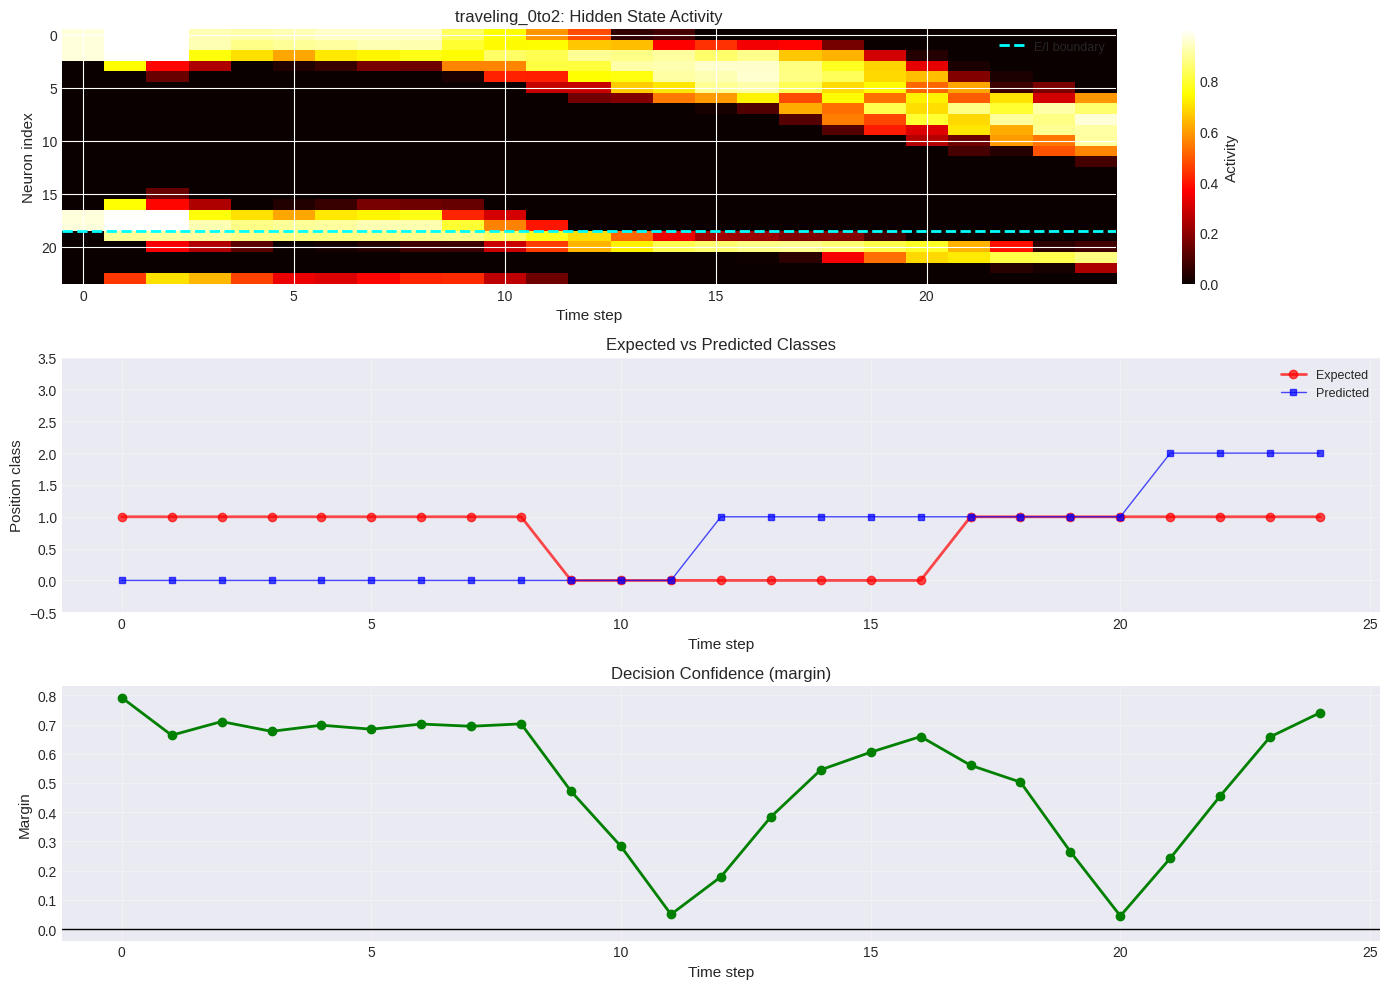


✓ Trajectory validation complete!


In [19]:
# Cell 7: Comprehensive Trajectory Validation
"""
Test all generated trajectories and diagnose any issues
"""

def validate_trajectory(ring, trajectory_dict, key, verbose=True):
    """
    Run trajectory through ring and compute accuracy.
    Handles different trajectory types (static, traveling, jumping).
    """
    inputs = trajectory_dict['inputs']
    gt = trajectory_dict['ground_truth']
    traj_type = gt['type']

    # Run forward pass
    output = ring.forward(inputs)
    predicted_classes = output['classes'][0].numpy()
    margin = output['margin'][0].numpy()

    # Compute expected classes per timestep
    duration = inputs.shape[1]
    if traj_type == 'static':
        expected_classes = np.full(duration, gt['position_class'])

    elif traj_type == 'traveling':
        # Reconstruct expected class at each timestep
        expected_classes = np.zeros(duration, dtype=int)
        for t in range(duration):
            # Find which class the ground truth neurons belong to
            gt_neurons = gt['important_neurons'][t]
            center = int(np.mean(gt_neurons))
            neurons_per_class = ring.N_exc / ring.K
            expected_classes[t] = int(center / neurons_per_class)

    elif traj_type == 'jumping':
        # Map each time window to its class
        expected_classes = np.zeros(duration, dtype=int)
        class_seq = gt['class_sequence']
        dur_per_class = gt['duration_per_class']
        for i, cls in enumerate(class_seq):
            start = i * dur_per_class
            end = (i + 1) * dur_per_class
            expected_classes[start:end] = cls

    # Compute accuracy
    accuracy = (predicted_classes == expected_classes).mean() * 100
    avg_margin = margin.mean()

    if verbose:
        print(f"\n{'='*60}")
        print(f"Trajectory: {key}")
        print(f"Type: {traj_type}")
        print(f"Duration: {duration} steps")
        print(f"Accuracy: {accuracy:.1f}%")
        print(f"Average margin: {avg_margin:.4f}")

        if accuracy < 95:
            # Show errors
            errors = np.where(predicted_classes != expected_classes)[0]
            print(f"⚠️  Errors at timesteps: {errors[:10]}...")  # Show first 10
            print(f"   Expected: {expected_classes[errors[:5]]}")
            print(f"   Predicted: {predicted_classes[errors[:5]]}")

    return {
        'accuracy': accuracy,
        'avg_margin': avg_margin,
        'predicted_classes': predicted_classes,
        'expected_classes': expected_classes,
        'output': output
    }

# Validate all trajectories
print("=== VALIDATING ALL TRAJECTORIES ===")
validation_results = {}

for key in trajectories.keys():
    result = validate_trajectory(ring_v3, trajectories[key], key, verbose=True)
    validation_results[key] = result

# Summary table
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(f"{'Trajectory':<25} {'Accuracy':<12} {'Avg Margin':<12}")
print("-"*60)

for key, result in validation_results.items():
    acc = result['accuracy']
    margin = result['avg_margin']
    status = "✓" if acc > 95 else "⚠️"
    print(f"{status} {key:<23} {acc:>6.1f}%      {margin:>8.4f}")

# Identify problematic trajectories
problematic = [k for k, v in validation_results.items() if v['accuracy'] < 95]

if problematic:
    print(f"\n⚠️  Problematic trajectories: {problematic}")
    print("\nInvestigating issues...")

    # Visualize the worst one
    worst_key = min(validation_results.keys(), key=lambda k: validation_results[k]['accuracy'])
    print(f"\nVisualizing worst case: {worst_key}")

    worst_traj = trajectories[worst_key]
    worst_result = validation_results[worst_key]
    worst_gt = worst_traj['ground_truth']

    # Use generic title and expected classes from validation
    if worst_gt['type'] == 'static':
        gt_class = worst_gt['position_class']
    else:
        # For non-static, just show the trajectory
        gt_class = None

    # Make a custom plot that shows expected vs predicted over time
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    hidden = worst_result['output']['hidden'][0].numpy()
    expected = worst_result['expected_classes']
    predicted = worst_result['predicted_classes']
    margin = worst_result['output']['margin'][0].numpy()

    # Panel A: Hidden states
    ax = axes[0]
    im = ax.imshow(hidden.T, aspect='auto', cmap='hot', interpolation='nearest')
    ax.set_ylabel('Neuron index')
    ax.set_xlabel('Time step')
    ax.set_title(f'{worst_key}: Hidden State Activity')
    ax.axhline(ring_v3.N_exc - 0.5, color='cyan', linewidth=2, linestyle='--', label='E/I boundary')
    plt.colorbar(im, ax=ax, label='Activity')
    ax.legend(loc='upper right')

    # Panel B: Expected vs Predicted
    ax = axes[1]
    ax.plot(expected, 'ro-', label='Expected', markersize=6, alpha=0.7, linewidth=2)
    ax.plot(predicted, 'bs-', label='Predicted', markersize=4, alpha=0.7, linewidth=1)
    ax.set_ylabel('Position class')
    ax.set_xlabel('Time step')
    ax.set_title('Expected vs Predicted Classes')
    ax.set_ylim(-0.5, ring_v3.K - 0.5)
    ax.legend()
    ax.grid(alpha=0.3)

    # Panel C: Margin
    ax = axes[2]
    ax.plot(margin, 'o-', color='green', markersize=6, linewidth=2)
    ax.axhline(0, color='k', linestyle='-', linewidth=1)
    ax.set_ylabel('Margin')
    ax.set_xlabel('Time step')
    ax.set_title('Decision Confidence (margin)')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("\n✓ All trajectories performing well!")

print("\n✓ Trajectory validation complete!")

In [20]:
# Cell 7 (REVISED): Comprehensive Trajectory Validation
"""
Test all generated trajectories with appropriate metrics per type
"""

def validate_trajectory(ring, trajectory_dict, key, verbose=True):
    """
    Run trajectory through ring and compute accuracy.
    Uses trajectory-appropriate metrics.
    """
    inputs = trajectory_dict['inputs']
    gt = trajectory_dict['ground_truth']
    traj_type = gt['type']

    # Run forward pass
    output = ring.forward(inputs)
    predicted_classes = output['classes'][0].numpy()
    margin = output['margin'][0].numpy()

    duration = inputs.shape[1]

    # Compute metrics based on trajectory type
    if traj_type == 'static':
        # Static: should match ground truth class at all timesteps
        expected_classes = np.full(duration, gt['position_class'])
        accuracy = (predicted_classes == expected_classes).mean() * 100
        metric_name = "Accuracy"

    elif traj_type == 'traveling':
        # Traveling: Check endpoints + monotonicity (bump should drift in right direction)
        start_class = gt['start_class']
        end_class = gt['end_class']
        shift_start, shift_end = gt['shift_window']

        # Check initial position (before shift starts)
        init_window = slice(0, shift_start)
        init_correct = (predicted_classes[init_window] == start_class).mean()

        # Check final position (after shift ends)
        final_window = slice(shift_end, duration)
        final_correct = (predicted_classes[final_window] == end_class).mean()

        # Check that position generally increases (if start < end) or decreases
        if end_class > start_class:
            # Should be mostly non-decreasing
            diffs = np.diff(predicted_classes)
            monotonic_score = (diffs >= 0).mean()
        else:
            # Should be mostly non-increasing
            diffs = np.diff(predicted_classes)
            monotonic_score = (diffs <= 0).mean()

        # Combined metric: weighted average
        accuracy = 0.4 * init_correct * 100 + 0.4 * final_correct * 100 + 0.2 * monotonic_score * 100
        metric_name = "Travel Score"

        # For display, reconstruct "expected" loosely
        expected_classes = np.zeros(duration, dtype=int)
        expected_classes[:shift_start] = start_class
        expected_classes[shift_end:] = end_class
        # During transition, show interpolated expectation
        for t in range(shift_start, shift_end):
            progress = (t - shift_start) / (shift_end - shift_start)
            expected_classes[t] = int(start_class + progress * (end_class - start_class))

    elif traj_type == 'jumping':
        # Jumping: Check each segment independently (allow brief transition periods)
        class_seq = gt['class_sequence']
        dur_per_class = gt['duration_per_class']
        transition_grace = 2  # Allow 2 steps for bump to stabilize after jump

        segment_accuracies = []
        expected_classes = np.zeros(duration, dtype=int)

        for i, cls in enumerate(class_seq):
            start = i * dur_per_class + transition_grace  # Skip first 2 steps
            end = (i + 1) * dur_per_class

            if start < end:  # Valid segment
                segment_pred = predicted_classes[start:end]
                segment_acc = (segment_pred == cls).mean()
                segment_accuracies.append(segment_acc)

            # Fill expected for display
            seg_start = i * dur_per_class
            seg_end = (i + 1) * dur_per_class
            expected_classes[seg_start:seg_end] = cls

        accuracy = np.mean(segment_accuracies) * 100
        metric_name = "Jump Accuracy"

    # Compute average margin
    avg_margin = margin.mean()

    if verbose:
        print(f"\n{'='*60}")
        print(f"Trajectory: {key}")
        print(f"Type: {traj_type}")
        print(f"Duration: {duration} steps")
        print(f"{metric_name}: {accuracy:.1f}%")
        print(f"Average margin: {avg_margin:.4f}")

        if traj_type == 'traveling' and verbose:
            # Show traveling-specific metrics
            init_correct_pct = init_correct * 100
            final_correct_pct = final_correct * 100
            mono_pct = monotonic_score * 100
            print(f"  Initial position correct: {init_correct_pct:.1f}%")
            print(f"  Final position correct: {final_correct_pct:.1f}%")
            print(f"  Monotonic drift: {mono_pct:.1f}%")

        if accuracy < 90:
            print(f"⚠️  Below 90% threshold")

    return {
        'accuracy': accuracy,
        'avg_margin': avg_margin,
        'predicted_classes': predicted_classes,
        'expected_classes': expected_classes,
        'output': output
    }

# Validate all trajectories
print("=== VALIDATING ALL TRAJECTORIES ===")
validation_results = {}

for key in trajectories.keys():
    result = validate_trajectory(ring_v3, trajectories[key], key, verbose=True)
    validation_results[key] = result

# Summary table
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(f"{'Trajectory':<25} {'Score':<12} {'Avg Margin':<12}")
print("-"*60)

for key, result in validation_results.items():
    acc = result['accuracy']
    margin = result['avg_margin']
    status = "✓" if acc > 90 else "⚠️"
    print(f"{status} {key:<23} {acc:>6.1f}%      {margin:>8.4f}")

# Identify any remaining issues
problematic = [k for k, v in validation_results.items() if v['accuracy'] < 90]

if problematic:
    print(f"\n⚠️  Trajectories below 90%: {problematic}")
else:
    print("\n✓ All trajectories performing well (>90%)!")

print("\n✓ Trajectory validation complete!")

=== VALIDATING ALL TRAJECTORIES ===

Trajectory: static_pos0
Type: static
Duration: 20 steps
Accuracy: 100.0%
Average margin: 0.7004

Trajectory: static_pos1
Type: static
Duration: 20 steps
Accuracy: 100.0%
Average margin: 0.6937

Trajectory: static_pos2
Type: static
Duration: 20 steps
Accuracy: 100.0%
Average margin: 0.8506

Trajectory: static_pos3
Type: static
Duration: 20 steps
Accuracy: 100.0%
Average margin: 0.8391

Trajectory: traveling_0to2
Type: traveling
Duration: 25 steps
Travel Score: 92.0%
Average margin: 0.5186
  Initial position correct: 100.0%
  Final position correct: 80.0%
  Monotonic drift: 100.0%

Trajectory: jumping_0_3_1
Type: jumping
Duration: 24 steps
Jump Accuracy: 100.0%
Average margin: 0.6611

SUMMARY TABLE
Trajectory                Score        Avg Margin  
------------------------------------------------------------
✓ static_pos0              100.0%        0.7004
✓ static_pos1              100.0%        0.6937
✓ static_pos2              100.0%        0.8506


#### Windowed Causal Interventions for Pos2

In [21]:
# Cell 8: Windowed Causal Interventions
"""
Implement activation patching methods for circuit discovery:
1. Soft ablation (necessity): Attenuate neuron activity, measure Δmargin
2. Trace patching (sufficiency): Copy neuron trace, measure Δmargin
3. Causal re-rollout: Effects propagate forward through recurrence

Based on the methods from the paper (Appendix B)
"""

class CausalInterventions:
    """Windowed causal intervention methods for circuit discovery"""

    def __init__(self, ring):
        self.ring = ring
        self.N = ring.N
        self.device = ring.device

    def _rollout_with_patched_hidden(self, inputs, patched_hidden, time_window=None):
        """
        Re-run dynamics with patched hidden states, allowing effects to propagate.

        Args:
            inputs: (batch, time, N) input sequence
            patched_hidden: (batch, time, N) patched hidden states
            time_window: (start, end) - only apply patch in this window, None = all time

        Returns:
            dict with 'hidden', 'logits', 'classes', 'margin'
        """
        batch_size, n_steps, _ = inputs.shape
        start_t, end_t = (0, n_steps) if time_window is None else time_window

        # Initialize
        h = torch.zeros(batch_size, self.N, device=self.device)

        hidden_states = []
        logits_seq = []
        classes_seq = []
        margins_seq = []

        for t in range(n_steps):
            x_t = inputs[:, t, :]

            # Standard recurrent step
            a = torch.matmul(h, self.ring.W_hh.t()) + torch.matmul(x_t, self.ring.W_ih.t())
            u = torch.tanh(a)
            h = torch.clamp(u, min=0.0)  # ReLU

            # Apply patch if within window
            if start_t <= t < end_t:
                h = patched_hidden[:, t, :].to(self.device)
                h = torch.clamp(h, min=0.0)  # Ensure non-negative

            # Readout
            z = torch.matmul(h, self.ring.W_out.t()) + self.ring.b_out
            pred_class = torch.argmax(z, dim=-1)
            margin = self.ring._compute_margin(z, pred_class)

            # Store
            hidden_states.append(h.detach().cpu())
            logits_seq.append(z.detach().cpu())
            classes_seq.append(pred_class.detach().cpu())
            margins_seq.append(margin.detach().cpu())

        return {
            'hidden': torch.stack(hidden_states, dim=1),
            'logits': torch.stack(logits_seq, dim=1),
            'classes': torch.stack(classes_seq, dim=1),
            'margin': torch.stack(margins_seq, dim=1),
        }

    def soft_ablation(self, inputs, neuron_idx, time_window, alpha=0.05):
        """
        Soft ablation: Scale neuron activity by alpha within window.
        Measures necessity via Δmargin = mean(margin_base - margin_ablated) in window.

        Args:
            inputs: (batch, time, N) input sequence
            neuron_idx: int or list of neuron indices to ablate
            time_window: (start, end) timesteps
            alpha: scaling factor (0 = full ablation, 1 = no ablation)

        Returns:
            delta_margin: scalar, positive = neuron is necessary
        """
        # Baseline run
        base_output = self.ring.forward(inputs)
        base_margin = base_output['margin']  # (batch, time)

        # Create ablated hidden states
        patched_hidden = base_output['hidden'].clone()
        start_t, end_t = time_window

        if isinstance(neuron_idx, int):
            neuron_idx = [neuron_idx]

        # Scale selected neurons in window
        for idx in neuron_idx:
            patched_hidden[:, start_t:end_t, idx] *= alpha

        # Re-rollout with ablation
        ablated_output = self._rollout_with_patched_hidden(inputs, patched_hidden, time_window)
        ablated_margin = ablated_output['margin']  # (batch, time)

        # Compute mean Δmargin over window
        window_slice = slice(start_t, end_t)
        delta_margin = (base_margin[:, window_slice] - ablated_margin[:, window_slice]).mean().item()

        return delta_margin

    def trace_patching(self, source_inputs, target_inputs, neuron_idx, time_window):
        """
        Trace patching: Copy neuron's trajectory from source to target.
        Measures sufficiency via Δmargin = mean(margin_patched - margin_base) in window.

        Args:
            source_inputs: (batch, time, N) - "good" trajectory (e.g., with bump at correct position)
            target_inputs: (batch, time, N) - "corrupted" trajectory (e.g., wrong position)
            neuron_idx: int, neuron to patch
            time_window: (start, end) timesteps

        Returns:
            delta_margin: scalar, positive = neuron is sufficient to restore correct behavior
        """
        # Run source and target
        source_output = self.ring.forward(source_inputs)
        target_output = self.ring.forward(target_inputs)

        # Patch: copy source neuron into target hidden states
        patched_hidden = target_output['hidden'].clone()
        start_t, end_t = time_window
        patched_hidden[:, start_t:end_t, neuron_idx] = source_output['hidden'][:, start_t:end_t, neuron_idx]

        # Re-rollout with patch
        patched_output = self._rollout_with_patched_hidden(target_inputs, patched_hidden, time_window)

        # Compute Δmargin (improvement in target run)
        # Use source's ground truth class as reference for margin computation
        source_classes = source_output['classes']  # (batch, time)

        window_slice = slice(start_t, end_t)
        base_margin = target_output['margin'][:, window_slice].mean().item()
        patched_margin = patched_output['margin'][:, window_slice].mean().item()

        delta_margin = patched_margin - base_margin

        return delta_margin

    def identify_circuit(self, inputs, time_window, method='ablation', top_k=5, alpha=0.05,
                        source_inputs=None, verbose=True):
        """
        Identify top-k causally important neurons in a time window.

        Args:
            inputs: (batch, time, N) input sequence
            time_window: (start, end) timesteps
            method: 'ablation' (necessity) or 'patching' (sufficiency)
            top_k: number of neurons to identify
            alpha: ablation strength (only for method='ablation')
            source_inputs: required if method='patching'

        Returns:
            dict with 'importance' (full vector), 'top_neurons' (indices), 'scores' (values)
        """
        importance = torch.zeros(self.N)

        if verbose:
            print(f"Identifying circuit using {method} in window {time_window}...")

        # Score each neuron
        for n in range(self.N):
            if method == 'ablation':
                importance[n] = self.soft_ablation(inputs, n, time_window, alpha=alpha)
            elif method == 'patching':
                if source_inputs is None:
                    raise ValueError("source_inputs required for patching method")
                importance[n] = self.trace_patching(source_inputs, inputs, n, time_window)
            else:
                raise ValueError(f"Unknown method: {method}")

        # Get top-k
        top_k = min(top_k, self.N)
        scores, neurons = torch.topk(importance, k=top_k)

        if verbose:
            print(f"Top {top_k} neurons: {neurons.tolist()}")
            print(f"Scores: {scores.tolist()}")

        return {
            'importance': importance,
            'top_neurons': neurons,
            'scores': scores
        }

In [22]:
## Instantiate
interventions = CausalInterventions(ring_v3)
print("✓ Causal intervention methods implemented")

## Quick test: Identify circuit for static_pos2 trajectory
print("\n=== Quick Test: Static Position 2 ===")
test_inputs = trajectories['static_pos2']['inputs']
test_gt = trajectories['static_pos2']['ground_truth']

✓ Causal intervention methods implemented

=== Quick Test: Static Position 2 ===


In [23]:
# Test ablation in middle of trajectory
window = (8, 12)  # Maintenance period
circuit = interventions.identify_circuit(
    test_inputs,
    time_window=window,
    method='ablation',
    top_k=5,
    alpha=0.05,
    verbose=True
)

Identifying circuit using ablation in window (8, 12)...
Top 5 neurons: [9, 10, 8, 7, 11]
Scores: [0.1994050294160843, 0.1850370168685913, 0.18503698706626892, 0.13047966361045837, 0.13047964870929718]


In [24]:
# Compare to ground truth
gt_neurons = test_gt['important_neurons'][10]  # Ground truth at t=10
identified_neurons = circuit['top_neurons'].numpy()

overlap = set(gt_neurons).intersection(set(identified_neurons))
precision = len(overlap) / len(identified_neurons)
recall = len(overlap) / len(gt_neurons)

print(f"\nGround truth neurons: {gt_neurons}")
print(f"Identified neurons: {identified_neurons}")
print(f"Overlap: {list(overlap)}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

print("\n✓ Causal interventions ready for validation!")


Ground truth neurons: [7, 8, 9, 10, 11]
Identified neurons: [ 9 10  8  7 11]
Overlap: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Precision: 100.00%
Recall: 100.00%

✓ Causal interventions ready for validation!


#### Comprehensive validations

In [25]:
# Cell 9: Comprehensive Circuit Discovery Validation
"""
Systematically validate circuit discovery across all test trajectories.
Compute precision/recall metrics and test robustness.
"""

def validate_circuit_discovery(interventions, trajectory_dict, key,
                               window_size=5, stride=3, top_k=5,
                               method='ablation', alpha=0.05, verbose=True):
    """
    Validate circuit discovery on a trajectory using sliding windows.

    Args:
        interventions: CausalInterventions instance
        trajectory_dict: dict with 'inputs' and 'ground_truth'
        key: trajectory name
        window_size: width of sliding window
        stride: step size for sliding window
        top_k: number of neurons to identify
        method: 'ablation' or 'patching'
        alpha: ablation strength

    Returns:
        dict with per-window and aggregate metrics
    """
    inputs = trajectory_dict['inputs']
    gt = trajectory_dict['ground_truth']
    duration = inputs.shape[1]

    # Generate sliding windows
    windows = []
    for start in range(0, duration - window_size + 1, stride):
        end = start + window_size
        windows.append((start, end))

    if verbose:
        print(f"\n{'='*70}")
        print(f"Trajectory: {key}")
        print(f"Method: {method}, Window size: {window_size}, Stride: {stride}")
        print(f"Testing {len(windows)} windows")

    # Results storage
    window_results = []

    for win_idx, window in enumerate(windows):
        start_t, end_t = window
        center_t = (start_t + end_t) // 2

        # Identify circuit
        circuit = interventions.identify_circuit(
            inputs,
            time_window=window,
            method=method,
            top_k=top_k,
            alpha=alpha,
            verbose=False
        )

        identified = set(circuit['top_neurons'].numpy().tolist())

        # Get ground truth for center of window
        gt_neurons = set(gt['important_neurons'][center_t])

        # Compute metrics
        overlap = identified.intersection(gt_neurons)
        precision = len(overlap) / len(identified) if len(identified) > 0 else 0.0
        recall = len(overlap) / len(gt_neurons) if len(gt_neurons) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        window_results.append({
            'window': window,
            'center_t': center_t,
            'identified': identified,
            'ground_truth': gt_neurons,
            'overlap': overlap,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'importance': circuit['importance']
        })

        if verbose and win_idx < 3:  # Show first 3 windows
            print(f"\n  Window {window} (center t={center_t}):")
            print(f"    Ground truth: {sorted(gt_neurons)}")
            print(f"    Identified:   {sorted(identified)}")
            print(f"    Overlap:      {sorted(overlap)}")
            print(f"    Precision: {precision:.2%}, Recall: {recall:.2%}, F1: {f1:.2%}")

    # Aggregate statistics
    precisions = [r['precision'] for r in window_results]
    recalls = [r['recall'] for r in window_results]
    f1s = [r['f1'] for r in window_results]

    aggregate = {
        'mean_precision': np.mean(precisions),
        'mean_recall': np.mean(recalls),
        'mean_f1': np.mean(f1s),
        'std_precision': np.std(precisions),
        'std_recall': np.std(recalls),
        'std_f1': np.std(f1s),
        'min_precision': np.min(precisions),
        'min_recall': np.min(recalls),
        'num_windows': len(windows)
    }

    if verbose:
        print(f"\n  {'Aggregate Metrics':-^60}")
        print(f"    Mean Precision: {aggregate['mean_precision']:.2%} ± {aggregate['std_precision']:.2%}")
        print(f"    Mean Recall:    {aggregate['mean_recall']:.2%} ± {aggregate['std_recall']:.2%}")
        print(f"    Mean F1:        {aggregate['mean_f1']:.2%} ± {aggregate['std_f1']:.2%}")
        print(f"    Min Precision:  {aggregate['min_precision']:.2%}")
        print(f"    Min Recall:     {aggregate['min_recall']:.2%}")

    return {
        'window_results': window_results,
        'aggregate': aggregate,
        'trajectory_key': key,
        'trajectory_type': gt['type']
    }

In [26]:
# Run comprehensive validation
print("="*70)
print("COMPREHENSIVE CIRCUIT DISCOVERY VALIDATION")
print("="*70)

validation_results = {}

COMPREHENSIVE CIRCUIT DISCOVERY VALIDATION


In [27]:
# Test on all static trajectories (should have stable circuits)
for key in ['static_pos0', 'static_pos1', 'static_pos2', 'static_pos3']:
    result = validate_circuit_discovery(
        interventions,
        trajectories[key],
        key,
        window_size=5,
        stride=5,  # Non-overlapping windows
        top_k=5,
        method='ablation',
        alpha=0.05,
        verbose=True
    )
    validation_results[key] = result


Trajectory: static_pos0
Method: ablation, Window size: 5, Stride: 5
Testing 4 windows

  Window (0, 5) (center t=2):
    Ground truth: [0, 1, 2, 17, 18]
    Identified:   [0, 1, 16, 17, 18]
    Overlap:      [0, 1, 17, 18]
    Precision: 80.00%, Recall: 80.00%, F1: 80.00%

  Window (5, 10) (center t=7):
    Ground truth: [0, 1, 2, 17, 18]
    Identified:   [0, 1, 16, 17, 18]
    Overlap:      [0, 1, 17, 18]
    Precision: 80.00%, Recall: 80.00%, F1: 80.00%

  Window (10, 15) (center t=12):
    Ground truth: [0, 1, 2, 17, 18]
    Identified:   [0, 1, 16, 17, 18]
    Overlap:      [0, 1, 17, 18]
    Precision: 80.00%, Recall: 80.00%, F1: 80.00%

  ---------------------Aggregate Metrics----------------------
    Mean Precision: 85.00% ± 8.66%
    Mean Recall:    85.00% ± 8.66%
    Mean F1:        85.00% ± 8.66%
    Min Precision:  80.00%
    Min Recall:     80.00%

Trajectory: static_pos1
Method: ablation, Window size: 5, Stride: 5
Testing 4 windows

  Window (0, 5) (center t=2):
    Gro

In [28]:
# Test on traveling trajectory (circuit should shift over time)
print("\n" + "="*70)
print("TRAVELING BUMP (Circuit should change over time)")
print("="*70)
result = validate_circuit_discovery(
    interventions,
    trajectories['traveling_0to2'],
    'traveling_0to2',
    window_size=5,
    stride=5,
    top_k=5,
    method='ablation',
    alpha=0.05,
    verbose=True
)
validation_results['traveling_0to2'] = result


TRAVELING BUMP (Circuit should change over time)

Trajectory: traveling_0to2
Method: ablation, Window size: 5, Stride: 5
Testing 5 windows

  Window (0, 5) (center t=2):
    Ground truth: [0, 1, 2, 17, 18]
    Identified:   [0, 1, 16, 17, 18]
    Overlap:      [0, 1, 17, 18]
    Precision: 80.00%, Recall: 80.00%, F1: 80.00%

  Window (5, 10) (center t=7):
    Ground truth: [0, 1, 2, 17, 18]
    Identified:   [0, 1, 16, 17, 18]
    Overlap:      [0, 1, 17, 18]
    Precision: 80.00%, Recall: 80.00%, F1: 80.00%

  Window (10, 15) (center t=12):
    Ground truth: [2, 3, 4, 5, 6]
    Identified:   [3, 4, 5, 6, 18]
    Overlap:      [3, 4, 5, 6]
    Precision: 80.00%, Recall: 80.00%, F1: 80.00%

  ---------------------Aggregate Metrics----------------------
    Mean Precision: 68.00% ± 34.87%
    Mean Recall:    68.00% ± 34.87%
    Mean F1:        68.00% ± 34.87%
    Min Precision:  0.00%
    Min Recall:     0.00%


In [29]:
# Test on jumping trajectory (circuit should switch at transitions)
print("\n" + "="*70)
print("JUMPING BUMP (Circuit should switch discretely)")
print("="*70)
result = validate_circuit_discovery(
    interventions,
    trajectories['jumping_0_3_1'],
    'jumping_0_3_1',
    window_size=5,
    stride=4,
    top_k=5,
    method='ablation',
    alpha=0.05,
    verbose=True
)
validation_results['jumping_0_3_1'] = result


JUMPING BUMP (Circuit should switch discretely)

Trajectory: jumping_0_3_1
Method: ablation, Window size: 5, Stride: 4
Testing 5 windows

  Window (0, 5) (center t=2):
    Ground truth: [0, 1, 2, 17, 18]
    Identified:   [0, 1, 16, 17, 18]
    Overlap:      [0, 1, 17, 18]
    Precision: 80.00%, Recall: 80.00%, F1: 80.00%

  Window (4, 9) (center t=6):
    Ground truth: [0, 1, 2, 17, 18]
    Identified:   [0, 1, 14, 17, 18]
    Overlap:      [0, 1, 17, 18]
    Precision: 80.00%, Recall: 80.00%, F1: 80.00%

  Window (8, 13) (center t=10):
    Ground truth: [12, 13, 14, 15, 16]
    Identified:   [12, 13, 14, 15, 16]
    Overlap:      [12, 13, 14, 15, 16]
    Precision: 100.00%, Recall: 100.00%, F1: 100.00%

  ---------------------Aggregate Metrics----------------------
    Mean Precision: 92.00% ± 9.80%
    Mean Recall:    92.00% ± 9.80%
    Mean F1:        92.00% ± 9.80%
    Min Precision:  80.00%
    Min Recall:     80.00%


In [30]:
# Summary table
print("\n" + "="*70)
print("SUMMARY: Circuit Discovery Performance")
print("="*70)
print(f"{'Trajectory':<20} {'Type':<12} {'Precision':<15} {'Recall':<15} {'F1':<10}")
print("-"*70)

for key, result in validation_results.items():
    agg = result['aggregate']
    traj_type = result['trajectory_type']
    prec_str = f"{agg['mean_precision']:.1%} ± {agg['std_precision']:.1%}"
    rec_str = f"{agg['mean_recall']:.1%} ± {agg['std_recall']:.1%}"
    f1_str = f"{agg['mean_f1']:.1%}"

    print(f"{key:<20} {traj_type:<12} {prec_str:<15} {rec_str:<15} {f1_str:<10}")

print("\n✓ Comprehensive validation complete!")


SUMMARY: Circuit Discovery Performance
Trajectory           Type         Precision       Recall          F1        
----------------------------------------------------------------------
static_pos0          static       85.0% ± 8.7%    85.0% ± 8.7%    85.0%     
static_pos1          static       85.0% ± 8.7%    85.0% ± 8.7%    85.0%     
static_pos2          static       100.0% ± 0.0%   100.0% ± 0.0%   100.0%    
static_pos3          static       100.0% ± 0.0%   100.0% ± 0.0%   100.0%    
traveling_0to2       traveling    68.0% ± 34.9%   68.0% ± 34.9%   68.0%     
jumping_0_3_1        jumping      92.0% ± 9.8%    92.0% ± 9.8%    92.0%     

✓ Comprehensive validation complete!


#### TRL and circuit visualization

In [31]:
# Cell 10: Time-Resolved Linearization & Dynamic Circuit Visualization
"""
Visualize dynamic effective connectivity using time-resolved linearization.
Method: S[i,j,t] = gate[i,t] × W_hh[i,j] × h[t-1,j]

Node sizes follow per-timestep batch-averaged normalization:
  s_i(t) = 200 + 800 × (h̄_i(t) - min_j h̄_j(t)) / (max_j h̄_j(t) - min_j h̄_j(t) + ε)
"""

class TimeResolvedLinearization:
    """Compute and visualize dynamic effective connectivity"""

    def __init__(self, ring):
        self.ring = ring
        self.N = ring.N
        self.device = ring.device

    def compute_effective_connectivity(self, trajectory_output, timestep):
        """
        Compute effective connectivity at a specific timestep.
        Returns S[j→i,t] = gate[i,t] × W_hh[i,j] × h[t-1,j]

        Args:
            trajectory_output: dict from ring.forward() with 'hidden', 'pre_act', 'tanh_act'
            timestep: int, which timestep to analyze

        Returns:
            S: (N, N) effective connectivity matrix at time t
        """
        if timestep == 0:
            return torch.zeros(self.N, self.N)

        # Batch-averaged hidden state at t-1
        h_prev = trajectory_output['hidden'][:, timestep-1, :].mean(dim=0).to(self.device)  # [N]

        # Compute postsynaptic gain
        if 'pre_act' in trajectory_output and 'tanh_act' in trajectory_output:
            a_t = trajectory_output['pre_act'][:, timestep, :].mean(dim=0).to(self.device)
            u_t = trajectory_output['tanh_act'][:, timestep, :].mean(dim=0).to(self.device)
        else:
            # Approximate if not available
            h_t = trajectory_output['hidden'][:, timestep, :].mean(dim=0).to(self.device)
            u_t = h_t
            a_t = torch.atanh(torch.clamp(u_t, -0.99, 0.99))

        # Gate: (1 - tanh²(a)) × 1{tanh(a) > 0}
        tanh_deriv = 1.0 - u_t**2
        relu_mask = (u_t > 0).float()
        gate = tanh_deriv * relu_mask  # [N]

        # Components
        W_hh = self.ring.W_hh.cpu().numpy()
        signal = h_prev.cpu().numpy()
        gate_np = gate.cpu().numpy()

        # S[i,j] = gate[i] × W_hh[i,j] × signal[j]
        S = gate_np[:, None] * W_hh * signal[None, :]

        return torch.from_numpy(S).float()

    def visualize_circuit_over_time(self, trajectory_dict, circuit_neurons,
                                    timesteps, title="Circuit Dynamics",
                                    top_edges=30, save_path=None):
        """
        Visualize dynamic circuit at multiple timesteps with correct node sizing.

        Args:
            trajectory_dict: dict with 'inputs' and 'ground_truth'
            circuit_neurons: list/tensor of neuron indices to visualize
            timesteps: list of timesteps to show (e.g., [7, 8, 9])
            title: figure title
            top_edges: number of strongest edges to show per panel
            save_path: path to save figure
        """
        import numpy as np
        import matplotlib.pyplot as plt
        from matplotlib.patches import FancyArrowPatch

        # Run forward pass with intermediates
        inputs = trajectory_dict['inputs']
        output = self.ring.forward(inputs, return_intermediates=True)

        # Get neuron types
        neuron_types = self.ring.neuron_types if hasattr(self.ring, 'neuron_types') else None

        # Convert to list
        if torch.is_tensor(circuit_neurons):
            circuit_neurons = circuit_neurons.cpu().numpy().tolist()
        circuit_neurons = sorted(circuit_neurons)
        k = len(circuit_neurons)

        # Create figure
        n_panels = len(timesteps)
        fig, axes = plt.subplots(1, n_panels, figsize=(5.5*n_panels, 5.5))
        if n_panels == 1:
            axes = [axes]

        for ax_idx, t in enumerate(timesteps):
            ax = axes[ax_idx]

            # Effective connectivity at time t
            S = self.compute_effective_connectivity(output, t)
            S_sub = S[circuit_neurons][:, circuit_neurons].numpy()

            # CORRECTED: Batch-averaged hidden activities at time t
            h_bar_t = output['hidden'][:, t, circuit_neurons].mean(dim=0).numpy()  # [k]

            # Per-panel normalization (as specified in formula)
            h_min = h_bar_t.min()
            h_max = h_bar_t.max()
            eps = 1e-6

            node_sizes = 200 + 800 * (h_bar_t - h_min) / (h_max - h_min + eps)

            # Circular layout
            theta = np.linspace(0, 2*np.pi, k, endpoint=False)
            R = 1.0
            pos = np.c_[R*np.cos(theta), R*np.sin(theta)]

            # Find top edges
            edge_mags = np.abs(S_sub)
            np.fill_diagonal(edge_mags, 0)
            flat = edge_mags.ravel()
            keep_idx = np.argsort(flat)[::-1][:top_edges]
            keep_rc = np.column_stack(np.unravel_index(keep_idx, edge_mags.shape))

            # Draw edges
            for (i, j) in keep_rc:
                if i == j:
                    continue
                x1, y1 = pos[j]  # Source
                x2, y2 = pos[i]  # Target

                weight = S_sub[i, j]
                color = '#d62728' if weight >= 0 else '#1f77b4'
                width = 0.5 + 4.5 * (edge_mags[i, j] / (flat.max() + 1e-9))

                arrow = FancyArrowPatch(
                    (x1, y1), (x2, y2),
                    arrowstyle='-|>', mutation_scale=12,
                    linewidth=width, color=color, alpha=0.7, zorder=2
                )
                ax.add_patch(arrow)

            # Draw nodes with size proportional to batch-averaged activity
            for i in range(k):
                neuron_idx = circuit_neurons[i]

                # Color by E/I type
                if neuron_types is not None:
                    col = '#d62728' if neuron_types[neuron_idx] > 0 else '#1f77b4'
                else:
                    col = '#777777'

                # Node with correct size
                ax.scatter([pos[i, 0]], [pos[i, 1]], s=node_sizes[i],
                          c=col, edgecolors='#111111', linewidths=2, zorder=3)

                # Label
                ax.text(pos[i, 0], pos[i, 1], str(neuron_idx),
                       color='white', ha='center', va='center', fontsize=9,
                       weight='bold', zorder=4)

            ax.set_xlim(-1.5, 1.5)
            ax.set_ylim(-1.5, 1.5)
            ax.set_aspect('equal')
            ax.axis('off')
            ax.set_title(f't = {t}', fontsize=13, weight='bold')

        # Legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
                  markersize=12, label='Excitatory (E)', markeredgecolor='k', markeredgewidth=1.5),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4',
                  markersize=12, label='Inhibitory (I)', markeredgecolor='k', markeredgewidth=1.5),
            Line2D([0], [0], color='#d62728', lw=3, label='E→ connection'),
            Line2D([0], [0], color='#1f77b4', lw=3, label='I→ connection')
        ]
        axes[-1].legend(handles=legend_elements, loc='upper left',
                       bbox_to_anchor=(1.05, 1), frameon=True, fontsize=10)

        fig.suptitle(title, fontsize=15, y=0.98, weight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved: {save_path}")

        plt.show()
        return fig

In [32]:
# Instantiate
trl = TimeResolvedLinearization(ring_v3)

print("✓ Time-resolved linearization implemented (corrected)")

✓ Time-resolved linearization implemented (corrected)


In [33]:
# Test: Jumping bump with both circuits + inhibitory neurons
print("\n=== Jumping Bump: Position 0→3 Transition ===")

# Include neurons from both positions AND inhibitory neurons
position_0_neurons = [0, 1, 17, 18]
position_3_neurons = [12, 13, 14, 15, 16]
inhibitory_neurons = [19, 20]  # Show inhibitory influence

circuit_neurons_full = sorted(position_0_neurons + position_3_neurons + inhibitory_neurons)

print(f"Position 0 (E): {position_0_neurons}")
print(f"Position 3 (E): {position_3_neurons}")
print(f"Inhibitory (I): {inhibitory_neurons}")
print(f"Full circuit: {circuit_neurons_full}")
print(f"\nVisualizing at t=7, 8, 9 (before/during/after transition)")


=== Jumping Bump: Position 0→3 Transition ===
Position 0 (E): [0, 1, 17, 18]
Position 3 (E): [12, 13, 14, 15, 16]
Inhibitory (I): [19, 20]
Full circuit: [0, 1, 12, 13, 14, 15, 16, 17, 18, 19, 20]

Visualizing at t=7, 8, 9 (before/during/after transition)


In [34]:
# Diagnostic: Check activities
test_output = ring_v3.forward(trajectories['jumping_0_3_1']['inputs'],
                              return_intermediates=True)
print("\nActivity diagnostics (batch-averaged):")
for t in [7, 8, 9]:
    h_bar_t = test_output['hidden'][:, t, :].mean(dim=0).numpy()
    print(f"  t={t}: pos0={h_bar_t[position_0_neurons].mean():.3f}, "
          f"pos3={h_bar_t[position_3_neurons].mean():.3f}")


Activity diagnostics (batch-averaged):
  t=7: pos0=0.880, pos3=0.033
  t=8: pos0=0.730, pos3=0.912
  t=9: pos0=0.693, pos3=0.992


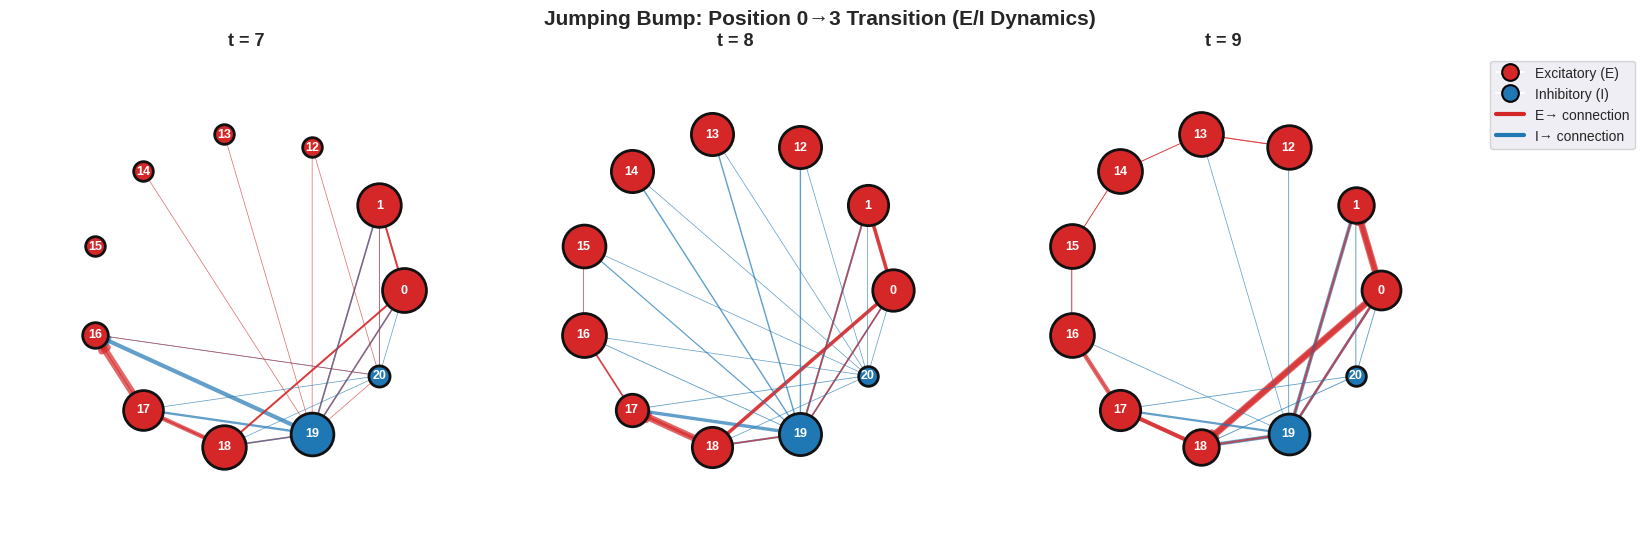


✓ Expected dynamics:
  t=7: Nodes 0,1,17,18 LARGE (active), nodes 12-16 SMALL (inactive)
  t=8: Transition - mixed activity
  t=9: Nodes 12-16 LARGE (active), nodes 0,1,17,18 SMALL (inactive)
  Inhibitory nodes (19,20) show blue edges to excitatory neurons


In [35]:
# Visualize
trl.visualize_circuit_over_time(
    trajectories['jumping_0_3_1'],
    circuit_neurons=circuit_neurons_full,
    timesteps=[7, 8, 9],
    title="Jumping Bump: Position 0→3 Transition (E/I Dynamics)",
    top_edges=30,
    save_path=None
)

print("\n✓ Expected dynamics:")
print("  t=7: Nodes 0,1,17,18 LARGE (active), nodes 12-16 SMALL (inactive)")
print("  t=8: Transition - mixed activity")
print("  t=9: Nodes 12-16 LARGE (active), nodes 0,1,17,18 SMALL (inactive)")
print("  Inhibitory nodes (19,20) show blue edges to excitatory neurons")

In [36]:
# # Test: Visualize jumping bump around transition at t=8
# print("\n=== Test: Jumping Bump (0→3 transition at t=8) ===")

# # Get circuit from previous validation
# jumping_result = validation_results['jumping_0_3_1']
# # Use neurons from window that captured the transition
# window_with_transition = jumping_result['window_results'][2]  # Window (8,13)
# identified_neurons = list(window_with_transition['identified'])[:10]  # Top 10

# print(f"Visualizing top circuit neurons: {identified_neurons}")
# print(f"Showing dynamics at t=7, 8, 9 (before/during/after jump)")

In [37]:
# trl.visualize_circuit_over_time(
#     trajectories['jumping_0_3_1'],
#     circuit_neurons=identified_neurons,
#     timesteps=[7, 8, 9],
#     title="Jumping Bump: Position 0→3 Transition",
#     top_edges=25,
#     save_path=None
# )

# print("\n✓ Time-resolved visualization ready!")

In [38]:
# # Cell 10b: Fixed Transition Visualization
# """
# Show transition by including neurons from BOTH source and target positions
# """

# print("=== Fixed: Jumping Bump Transition (Including Both Positions) ===")

# # Manually specify neurons from both positions to show the transition
# position_0_neurons = [0, 1, 17, 18]  # Position 0 circuit
# position_3_neurons = [12, 13, 14, 15, 16]  # Position 3 circuit

# # Combine both (this is the "extended circuit" for transition analysis)
# transition_neurons = sorted(position_0_neurons + position_3_neurons)

# print(f"Position 0 neurons: {position_0_neurons}")
# print(f"Position 3 neurons: {position_3_neurons}")
# print(f"Combined for visualization: {transition_neurons}")
# print(f"\nShowing dynamics at t=7, 8, 9 (before/during/after jump)")

# trl.visualize_circuit_over_time(
#     trajectories['jumping_0_3_1'],
#     circuit_neurons=transition_neurons,
#     timesteps=[7, 8, 9],
#     title="Jumping Bump: Position 0→3 Transition (Both Circuits)",
#     top_edges=30,
#     save_path=None
# )

# print("\n✓ Now you should see:")
# print("  t=7: Nodes 0,1,17,18 (position 0) are LARGE, nodes 12-16 (position 3) are SMALL")
# print("  t=8: TRANSITION - both sets active, complex connectivity")
# print("  t=9: Nodes 12-16 (position 3) are LARGE, nodes 0,1,17,18 (position 0) are SMALL")

#### Static bump visualizations

VISUALIZATION 1: Static Bump (Stable Circuit)
Position 2 neurons: [7, 8, 9, 10, 11]
Inhibitory neurons: [19, 20]
Circuit: [7, 8, 9, 10, 11, 19, 20]

Visualizing at t=5, 10, 15 (maintenance period)

Activity diagnostics (batch-averaged):
  t=5: pos2=0.835, inh=0.000
  t=10: pos2=0.868, inh=0.000
  t=15: pos2=0.865, inh=0.000


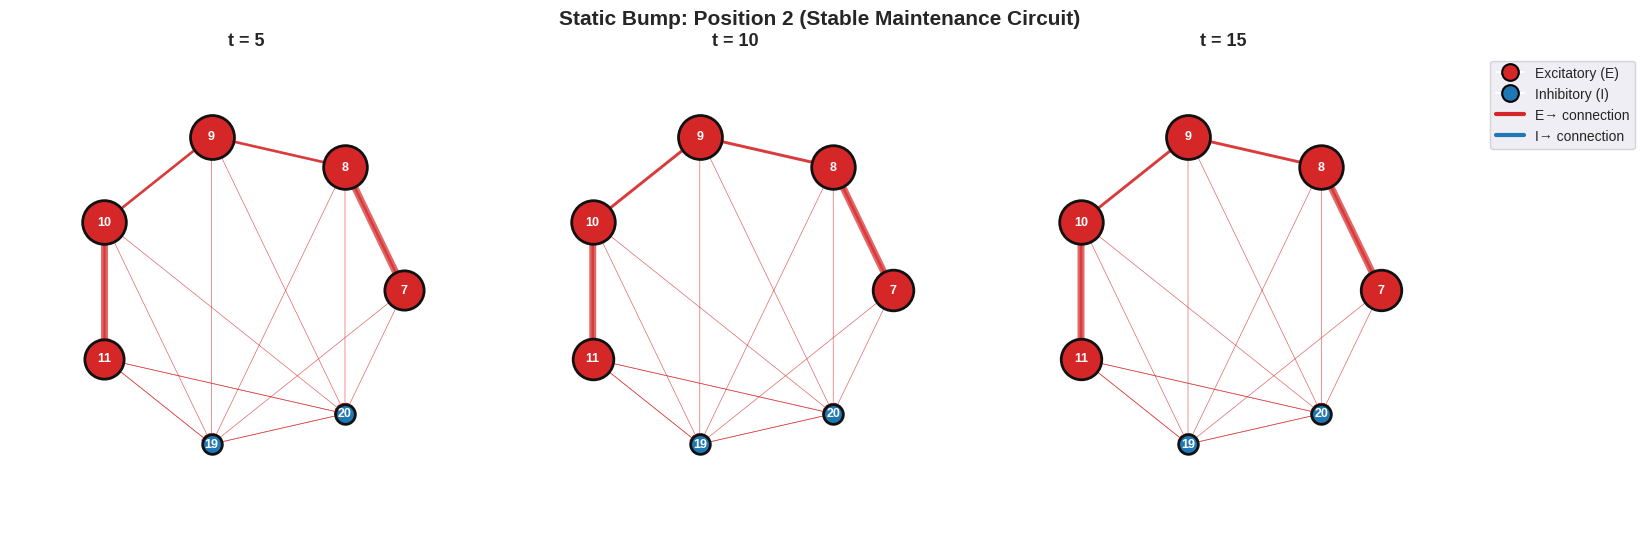


✓ Expected: Node sizes and connectivity should be nearly IDENTICAL across all 3 panels
  (Demonstrating stable memory maintenance)


In [39]:
# Cell 11: Static and Traveling Bump Visualizations
"""
Compare circuit dynamics across different trajectory types:
1. Static bump: Circuit should be stable over time
2. Traveling bump: Circuit should smoothly shift as bump drifts
"""

print("="*70)
print("VISUALIZATION 1: Static Bump (Stable Circuit)")
print("="*70)

# Static bump at position 2 (middle of ring, 100% accuracy)
position_2_neurons = [7, 8, 9, 10, 11]
inhibitory_neurons = [19, 20]
circuit_static = sorted(position_2_neurons + inhibitory_neurons)

print(f"Position 2 neurons: {position_2_neurons}")
print(f"Inhibitory neurons: {inhibitory_neurons}")
print(f"Circuit: {circuit_static}")
print(f"\nVisualizing at t=5, 10, 15 (maintenance period)")

# Diagnostic
static_output = ring_v3.forward(trajectories['static_pos2']['inputs'],
                                return_intermediates=True)
print("\nActivity diagnostics (batch-averaged):")
for t in [5, 10, 15]:
    h_bar_t = static_output['hidden'][:, t, :].mean(dim=0).numpy()
    print(f"  t={t}: pos2={h_bar_t[position_2_neurons].mean():.3f}, "
          f"inh={h_bar_t[inhibitory_neurons].mean():.3f}")

trl.visualize_circuit_over_time(
    trajectories['static_pos2'],
    circuit_neurons=circuit_static,
    timesteps=[5, 10, 15],
    title="Static Bump: Position 2 (Stable Maintenance Circuit)",
    top_edges=25,
    save_path=None
)

print("\n✓ Expected: Node sizes and connectivity should be nearly IDENTICAL across all 3 panels")
print("  (Demonstrating stable memory maintenance)")


VISUALIZATION 2: Traveling Bump (Smoothly Shifting Circuit)
Position 0 representatives: [0, 1, 17]
Position 1 representatives: [4, 5]
Position 2 representatives: [9, 10]
Inhibitory neurons: [19, 20]
Circuit: [0, 1, 4, 5, 9, 10, 17, 19, 20]

Visualizing at t=5, 12, 20 (before drift, during drift, after drift)

Activity diagnostics (batch-averaged):
  t=5: pos0=0.811, pos1=0.000, pos2=0.000
  t=12: pos0=0.380, pos1=0.516, pos2=0.000
  t=20: pos0=0.000, pos1=0.585, pos2=0.285


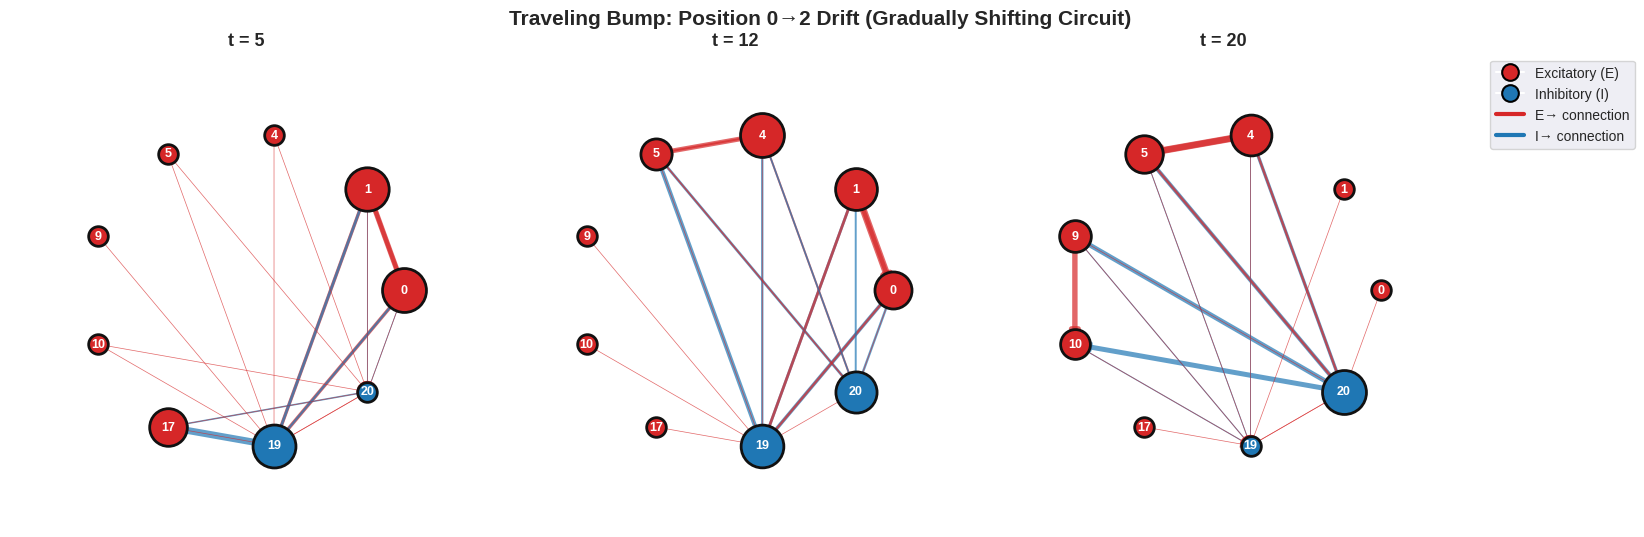


✓ Expected:
  t=5:  Nodes 0,1,17 (position 0) LARGE, nodes 9,10 (position 2) SMALL
  t=12: Transition - nodes 4,5 (position 1) becoming active
  t=20: Nodes 9,10 (position 2) LARGE, nodes 0,1,17 (position 0) SMALL
  (Demonstrating smooth activity shift as bump drifts)

SUMMARY: Three Types of Circuit Dynamics
✓ STATIC:    Same nodes active, same connectivity → memory maintenance
✓ TRAVELING: Gradual shift in active nodes → smooth state transition
✓ JUMPING:   Abrupt switch between circuits → discrete state change


In [40]:
print("\n" + "="*70)
print("VISUALIZATION 2: Traveling Bump (Smoothly Shifting Circuit)")
print("="*70)

# Traveling bump: position 0→2 includes neurons from positions 0, 1, 2
# Need broader coverage to see the drift
position_0_neurons = [0, 1, 17, 18]
position_1_neurons = [2, 3, 4, 5, 6]
position_2_neurons = [7, 8, 9, 10, 11]
inhibitory_neurons = [19, 20]

# Use a subset for clarity (too many nodes gets messy)
# Show key representatives from each position
circuit_traveling = sorted([0, 1, 17,  # Position 0
                           4, 5,        # Position 1
                           9, 10,       # Position 2
                           19, 20])     # Inhibitory

print(f"Position 0 representatives: [0, 1, 17]")
print(f"Position 1 representatives: [4, 5]")
print(f"Position 2 representatives: [9, 10]")
print(f"Inhibitory neurons: {inhibitory_neurons}")
print(f"Circuit: {circuit_traveling}")
print(f"\nVisualizing at t=5, 12, 20 (before drift, during drift, after drift)")

# Diagnostic
traveling_output = ring_v3.forward(trajectories['traveling_0to2']['inputs'],
                                   return_intermediates=True)
print("\nActivity diagnostics (batch-averaged):")
for t in [5, 12, 20]:
    h_bar_t = traveling_output['hidden'][:, t, :].mean(dim=0).numpy()
    print(f"  t={t}: pos0={h_bar_t[[0,1,17]].mean():.3f}, "
          f"pos1={h_bar_t[[4,5]].mean():.3f}, "
          f"pos2={h_bar_t[[9,10]].mean():.3f}")

trl.visualize_circuit_over_time(
    trajectories['traveling_0to2'],
    circuit_neurons=circuit_traveling,
    timesteps=[5, 12, 20],
    title="Traveling Bump: Position 0→2 Drift (Gradually Shifting Circuit)",
    top_edges=25,
    save_path=None
)

print("\n✓ Expected:")
print("  t=5:  Nodes 0,1,17 (position 0) LARGE, nodes 9,10 (position 2) SMALL")
print("  t=12: Transition - nodes 4,5 (position 1) becoming active")
print("  t=20: Nodes 9,10 (position 2) LARGE, nodes 0,1,17 (position 0) SMALL")
print("  (Demonstrating smooth activity shift as bump drifts)")

print("\n" + "="*70)
print("SUMMARY: Three Types of Circuit Dynamics")
print("="*70)
print("✓ STATIC:    Same nodes active, same connectivity → memory maintenance")
print("✓ TRAVELING: Gradual shift in active nodes → smooth state transition")
print("✓ JUMPING:   Abrupt switch between circuits → discrete state change")
print("="*70)

#### Additional metrics

In [41]:
# Cell 12: Extended Circuit Characterization Metrics
"""
Additional metrics beyond precision/recall:
1. Circuit sparsity (participation ratio, Gini coefficient)
2. Temporal stability (for static bumps)
3. E/I composition analysis
4. Edge statistics
"""

import numpy as np

def gini_coefficient(values):
    """
    Compute Gini coefficient (inequality measure).
    0 = perfect equality, 1 = maximal inequality

    Formula: G = (2 * Σ(i * x_i)) / (n * Σx_i) - (n+1)/n
    where x_i are sorted values
    """
    values = np.array(values).flatten()
    values = values[values >= 0]  # Only non-negative values

    if len(values) == 0 or values.sum() == 0:
        return 0.0

    # Sort values
    sorted_values = np.sort(values)
    n = len(sorted_values)

    # Compute Gini
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * sorted_values)) / (n * np.sum(sorted_values)) - (n + 1) / n

    return gini

class CircuitMetrics:
    """Extended metrics for circuit characterization"""

    def __init__(self, ring):
        self.ring = ring
        self.N = ring.N

    def participation_ratio(self, importance):
        """
        Participation ratio: (Σw_i)² / Σw_i²
        Measures effective number of neurons participating.
        PR=1 means only 1 neuron, PR=N means all equally important.
        """
        w = np.abs(importance.numpy())
        w = w / (w.sum() + 1e-9)  # Normalize
        pr = (w.sum() ** 2) / (np.square(w).sum() + 1e-9)
        return pr

    def gini_coefficient(self, importance):
        """
        Gini coefficient: measures inequality in importance distribution.
        0 = perfect equality, 1 = maximal inequality (one neuron dominates)
        """
        w = np.abs(importance.numpy())
        return gini_coefficient(w)

    def temporal_stability(self, circuit_results, metric='jaccard'):
        """
        Measure how stable the identified circuit is over time.

        Args:
            circuit_results: output from validate_circuit_discovery
            metric: 'jaccard' or 'cosine'

        Returns:
            mean stability across adjacent windows
        """
        windows = circuit_results['window_results']
        if len(windows) < 2:
            return 1.0

        stabilities = []
        for i in range(len(windows) - 1):
            set1 = windows[i]['identified']
            set2 = windows[i+1]['identified']

            if metric == 'jaccard':
                overlap = len(set1.intersection(set2))
                union = len(set1.union(set2))
                stability = overlap / union if union > 0 else 0
            elif metric == 'cosine':
                # Using importance vectors
                imp1 = windows[i]['importance'].numpy()
                imp2 = windows[i+1]['importance'].numpy()
                stability = np.dot(imp1, imp2) / (np.linalg.norm(imp1) * np.linalg.norm(imp2) + 1e-9)

            stabilities.append(stability)

        return np.mean(stabilities)

    def ei_composition(self, circuit_neurons):
        """Analyze E/I composition of identified circuit"""
        if not hasattr(self.ring, 'neuron_types'):
            return {'E': 0, 'I': 0, 'frac_I': np.nan}

        types = np.array(self.ring.neuron_types)[circuit_neurons]
        n_E = int((types > 0).sum())
        n_I = int((types < 0).sum())

        # Expected fraction if random
        total_I = int((np.array(self.ring.neuron_types) < 0).sum())
        expected_frac_I = total_I / self.N

        return {
            'n_E': n_E,
            'n_I': n_I,
            'frac_I': n_I / len(circuit_neurons) if len(circuit_neurons) > 0 else 0,
            'expected_frac_I': expected_frac_I,
            'I_enrichment': (n_I / len(circuit_neurons)) / (expected_frac_I + 1e-9) if len(circuit_neurons) > 0 else 0
        }

    def edge_statistics(self, effective_connectivity, circuit_neurons):
        """Analyze edge weight distribution and sign consistency"""
        S = effective_connectivity[circuit_neurons][:, circuit_neurons].numpy()
        np.fill_diagonal(S, 0)

        weights = S.ravel()
        weights = weights[weights != 0]

        if len(weights) == 0:
            return {}

        return {
            'mean_strength': np.abs(weights).mean(),
            'median_strength': np.median(np.abs(weights)),
            'frac_positive': (weights > 0).mean(),
            'frac_negative': (weights < 0).mean(),
            'max_strength': np.abs(weights).max()
        }

In [42]:
# Instantiate
metrics = CircuitMetrics(ring_v3)

print("="*70)
print("EXTENDED CIRCUIT METRICS")
print("="*70)

# Analyze all static trajectories
print("\n1. CIRCUIT SPARSITY (Participation Ratio & Gini)")
print("-"*70)
print(f"{'Trajectory':<20} {'PR':<8} {'Gini':<8} {'Interpretation'}")
print("-"*70)

for key in ['static_pos0', 'static_pos1', 'static_pos2', 'static_pos3']:
    result = validation_results[key]
    # Use importance from first window
    imp = result['window_results'][0]['importance']

    pr = metrics.participation_ratio(imp)
    gini_coef = metrics.gini_coefficient(imp)

    # Interpretation
    if pr > 10:
        interp = "Distributed"
    elif pr > 5:
        interp = "Moderate"
    else:
        interp = "Sparse"

    print(f"{key:<20} {pr:>6.2f}  {gini_coef:>6.3f}  {interp}")

# Temporal stability
print("\n2. TEMPORAL STABILITY (Circuit consistency over time)")
print("-"*70)
print(f"{'Trajectory':<20} {'Jaccard':<10} {'Cosine':<10} {'Interpretation'}")
print("-"*70)

for key in ['static_pos2', 'traveling_0to2', 'jumping_0_3_1']:
    result = validation_results[key]

    stab_jacc = metrics.temporal_stability(result, metric='jaccard')
    stab_cos = metrics.temporal_stability(result, metric='cosine')

    if stab_jacc > 0.9:
        interp = "Very stable"
    elif stab_jacc > 0.7:
        interp = "Moderate"
    else:
        interp = "Dynamic"

    print(f"{key:<20} {stab_jacc:>8.3f}  {stab_cos:>8.3f}  {interp}")

# E/I composition
print("\n3. E/I COMPOSITION ANALYSIS")
print("-"*70)
print(f"{'Trajectory':<20} {'E':<5} {'I':<5} {'Frac I':<8} {'Expected':<8} {'Enrichment'}")
print("-"*70)

for key in ['static_pos2', 'jumping_0_3_1']:
    result = validation_results[key]
    # Use neurons from window with best performance
    best_window = max(result['window_results'], key=lambda x: x['f1'])
    circuit_neurons = list(best_window['identified'])

    ei_stats = metrics.ei_composition(circuit_neurons)

    print(f"{key:<20} {ei_stats['n_E']:<5} {ei_stats['n_I']:<5} "
          f"{ei_stats['frac_I']:<8.3f} {ei_stats['expected_frac_I']:<8.3f} "
          f"{ei_stats['I_enrichment']:<8.2f}x")

print("\n✓ Extended metrics computed")
print("\nInterpretations:")
print("  - PR (Participation Ratio): Higher = more distributed circuit")
print("  - Gini: Higher = more concentrated in few neurons")
print("  - Stability: Higher = circuit composition consistent over time")
print("  - I Enrichment: >1 means inhibitory neurons over-represented in circuit")

EXTENDED CIRCUIT METRICS

1. CIRCUIT SPARSITY (Participation Ratio & Gini)
----------------------------------------------------------------------
Trajectory           PR       Gini     Interpretation
----------------------------------------------------------------------
static_pos0            4.53   0.825  Sparse
static_pos1            4.78   0.816  Sparse
static_pos2            4.93   0.804  Sparse
static_pos3            4.92   0.805  Sparse

2. TEMPORAL STABILITY (Circuit consistency over time)
----------------------------------------------------------------------
Trajectory           Jaccard    Cosine     Interpretation
----------------------------------------------------------------------
static_pos2             1.000     0.999  Very stable
traveling_0to2          0.444     0.351  Dynamic
jumping_0_3_1           0.444     0.470  Dynamic

3. E/I COMPOSITION ANALYSIS
----------------------------------------------------------------------
Trajectory           E     I     Frac I   Expec

In [43]:
# Cell 12b: Test Global vs Local Effects
"""
Distinguish between position-specific (local) and global modulatory neurons
"""

def test_global_vs_local_effect(interventions, trajectories_dict, neuron_idx, alpha=0.05):
    """
    Test if a neuron has position-specific or global effects.

    Method: Ablate neuron across all 4 position trajectories, measure Δmargin.
    - Local neuron: Large effect on one position, minimal on others
    - Global neuron: Similar effect across all positions

    Returns:
        effects: dict mapping position → Δmargin
        locality_score: variance of effects (high = local, low = global)
    """
    positions = [0, 1, 2, 3]
    effects = {}

    for pos in positions:
        key = f'static_pos{pos}'
        inputs = trajectories_dict[key]['inputs']
        window = (8, 12)  # Maintenance period

        delta_margin = interventions.soft_ablation(inputs, neuron_idx, window, alpha=alpha)
        effects[pos] = delta_margin

    # Locality score: variance of effects
    # High variance = position-specific (local)
    # Low variance = affects all equally (global)
    locality_score = np.var(list(effects.values()))

    return effects, locality_score

# print("\n" + "="*70)
# print("4. GLOBAL vs LOCAL NEURON CLASSIFICATION")
# print("="*70)

# Test representative neurons
test_neurons = {
    'Excitatory (pos 2)': 9,   # Should be local to position 2
    'Excitatory (pos 0)': 0,   # Should be local to position 0
    'Inhibitory 1': 19,         # Should be global
    'Inhibitory 2': 20,         # Should be global
}

# print(f"\n{'Neuron':<20} {'Pos0':<8} {'Pos1':<8} {'Pos2':<8} {'Pos3':<8} {'Locality':<10} {'Type'}")
# print("-"*70)

# for label, nidx in test_neurons.items():
#     effects, locality = test_global_vs_local_effect(interventions, trajectories, nidx, alpha=0.1)

#     # Classification
#     if locality > 0.01:
#         ntype = "LOCAL"
#     else:
#         ntype = "GLOBAL"

#     print(f"{label:<20} {effects[0]:>6.3f}  {effects[1]:>6.3f}  {effects[2]:>6.3f}  {effects[3]:>6.3f}  "
#           f"{locality:>8.4f}  {ntype}")

# print("\nInterpretation:")
# print("  - Local neurons: High variance (strong effect on one position, weak on others)")
# print("  - Global neurons: Low variance (similar effect across all positions)")
# print("  - Inhibitory neurons should be GLOBAL (normalization/competition)")
# print("  - Position-specific E neurons should be LOCAL")

In [44]:
# Cell 12c: Fixed Global vs Local Classification
"""
Better metrics for distinguishing position-specific vs global neurons
"""

def classify_neuron_locality(effects_dict):
    """
    Improved classification using multiple metrics.

    Args:
        effects_dict: {position: delta_margin}

    Returns:
        metrics dict with classification
    """
    effects = np.array(list(effects_dict.values()))

    # Metric 1: Specificity = max / (mean + eps)
    # High = effect concentrated in one position
    max_effect = np.max(np.abs(effects))
    mean_effect = np.mean(np.abs(effects))
    specificity = max_effect / (mean_effect + 1e-9)

    # Metric 2: Number of positions affected (threshold > 0.01)
    n_affected = np.sum(np.abs(effects) > 0.01)

    # Metric 3: Entropy (information-theoretic locality)
    # Normalize to distribution
    abs_effects = np.abs(effects) + 1e-9
    p = abs_effects / abs_effects.sum()
    entropy = -np.sum(p * np.log(p))
    max_entropy = np.log(len(effects))  # Uniform distribution
    normalized_entropy = entropy / max_entropy  # 0=specific, 1=global

    # Classification
    if specificity > 3.0 and n_affected == 1:
        classification = "LOCAL"
    elif specificity < 1.5 and n_affected >= 3:
        classification = "GLOBAL"
    else:
        classification = "INTERMEDIATE"

    return {
        'specificity': specificity,
        'n_affected': n_affected,
        'normalized_entropy': normalized_entropy,
        'classification': classification,
        'max_effect': max_effect
    }

print("\n" + "="*70)
print("4. GLOBAL vs LOCAL NEURON CLASSIFICATION (CORRECTED)")
print("="*70)

# Test representative neurons
test_neurons = {
    'E (pos 2, neuron 9)': 9,
    'E (pos 0, neuron 0)': 0,
    'E (pos 1, neuron 4)': 4,
    'Inhibitory 1 (19)': 19,
    'Inhibitory 2 (20)': 20,
}

print(f"\n{'Neuron':<22} {'Pos0':<7} {'Pos1':<7} {'Pos2':<7} {'Pos3':<7} {'Spec':<7} {'N_Aff':<7} {'Type'}")
print("-"*82)

for label, nidx in test_neurons.items():
    effects, _ = test_global_vs_local_effect(interventions, trajectories, nidx, alpha=0.1)
    metrics = classify_neuron_locality(effects)

    print(f"{label:<22} {effects[0]:>6.3f} {effects[1]:>6.3f} {effects[2]:>6.3f} {effects[3]:>6.3f} "
          f"{metrics['specificity']:>6.2f} {metrics['n_affected']:>7} {metrics['classification']:<12}")

print("\nMetrics:")
print("  - Specificity: max_effect / mean_effect (>3.0 = local, <1.5 = global)")
print("  - N_Aff: Number of positions with effect > 0.01")
print("  - Classification: LOCAL = specific to one position, GLOBAL = affects many")

# Additional test: Try stronger ablation for inhibitory neurons
print("\n" + "="*70)
print("5. INHIBITORY EFFECTS WITH STRONGER ABLATION")
print("="*70)

print(f"\n{'Neuron':<22} {'Alpha':<7} {'Pos0':<7} {'Pos1':<7} {'Pos2':<7} {'Pos3':<7} {'Classification'}")
print("-"*82)

for alpha_test in [0.05, 0.01, 0.0]:  # Progressively stronger ablation
    effects_i19, _ = test_global_vs_local_effect(interventions, trajectories, 19, alpha=alpha_test)
    metrics_i19 = classify_neuron_locality(effects_i19)

    print(f"Inhibitory 1 (19)      {alpha_test:<7.2f} {effects_i19[0]:>6.3f} {effects_i19[1]:>6.3f} "
          f"{effects_i19[2]:>6.3f} {effects_i19[3]:>6.3f} {metrics_i19['classification']:<12}")

print("\nInterpretation:")
print("  - If inhibitory effects are zero even with full ablation (alpha=0),")
print("    they may not be strongly recruited during static maintenance")
print("  - Inhibitory neurons may be more important during transitions")


4. GLOBAL vs LOCAL NEURON CLASSIFICATION (CORRECTED)

Neuron                 Pos0    Pos1    Pos2    Pos3    Spec    N_Aff   Type
----------------------------------------------------------------------------------
E (pos 2, neuron 9)     0.000  0.000  0.189  0.000   4.00       1 LOCAL       
E (pos 0, neuron 0)     0.188  0.000  0.000  0.000   4.00       1 LOCAL       
E (pos 1, neuron 4)     0.000  0.191  0.000  0.000   4.00       1 LOCAL       
Inhibitory 1 (19)       0.000  0.000  0.000  0.000   0.00       0 INTERMEDIATE
Inhibitory 2 (20)       0.000  0.000  0.000  0.000   0.00       0 INTERMEDIATE

Metrics:
  - Specificity: max_effect / mean_effect (>3.0 = local, <1.5 = global)
  - N_Aff: Number of positions with effect > 0.01
  - Classification: LOCAL = specific to one position, GLOBAL = affects many

5. INHIBITORY EFFECTS WITH STRONGER ABLATION

Neuron                 Alpha   Pos0    Pos1    Pos2    Pos3    Classification
----------------------------------------------------------

In [45]:
# Cell 12d: Test Inhibitory Role During Transitions
"""
Hypothesis: Inhibitory neurons are recruited for transitions, not maintenance
"""

print("="*70)
print("6. INHIBITORY NEURONS DURING TRANSITIONS")
print("="*70)

# Test during jumping bump transition
print("\n--- Jumping Bump: Position 0→3 Transition ---")
print(f"{'Neuron':<20} {'Window':<15} {'Δmargin':<10} {'Interpretation'}")
print("-"*70)

# Test different windows
test_neurons = {
    'E (pos 0, n=0)': 0,
    'E (pos 3, n=14)': 14,
    'Inhibitory 1 (19)': 19,
    'Inhibitory 2 (20)': 20,
}

jumping_inputs = trajectories['jumping_0_3_1']['inputs']

# Window 1: Before transition (maintenance at pos 0)
window_before = (4, 7)
print("\nBefore transition (t=4-7, stable at position 0):")
for label, nidx in test_neurons.items():
    delta = interventions.soft_ablation(jumping_inputs, nidx, window_before, alpha=0.05)
    print(f"  {label:<20} {str(window_before):<15} {delta:>8.4f}")

# Window 2: During transition (t=7-9)
window_during = (7, 9)
print("\nDuring transition (t=7-9, switching 0→3):")
for label, nidx in test_neurons.items():
    delta = interventions.soft_ablation(jumping_inputs, nidx, window_during, alpha=0.05)
    interp = "**IMPORTANT**" if delta > 0.05 else ""
    print(f"  {label:<20} {str(window_during):<15} {delta:>8.4f}  {interp}")

# Window 3: After transition (maintenance at pos 3)
window_after = (12, 16)
print("\nAfter transition (t=12-16, stable at position 3):")
for label, nidx in test_neurons.items():
    delta = interventions.soft_ablation(jumping_inputs, nidx, window_after, alpha=0.05)
    print(f"  {label:<20} {str(window_after):<15} {delta:>8.4f}")

# Check inhibitory activity levels
print("\n" + "="*70)
print("7. INHIBITORY NEURON ACTIVITY LEVELS")
print("="*70)

# Get forward pass output
jumping_output = ring_v3.forward(jumping_inputs, return_intermediates=True)

print(f"\n{'Condition':<25} {'Inh 19':<10} {'Inh 20':<10} {'E (avg)':<10}")
print("-"*70)

# Before transition
h_before = jumping_output['hidden'][:, 5, :].mean(dim=0).numpy()
print(f"Before (t=5, pos 0)       {h_before[19]:>8.3f}  {h_before[20]:>8.3f}  "
      f"{h_before[[0,1,17,18]].mean():>8.3f}")

# During transition
h_during = jumping_output['hidden'][:, 8, :].mean(dim=0).numpy()
print(f"During (t=8, switching)   {h_during[19]:>8.3f}  {h_during[20]:>8.3f}  "
      f"{h_during[[0,1,14,15,16]].mean():>8.3f}")

# After transition
h_after = jumping_output['hidden'][:, 14, :].mean(dim=0).numpy()
print(f"After (t=14, pos 3)       {h_after[19]:>8.3f}  {h_after[20]:>8.3f}  "
      f"{h_after[[14,15,16]].mean():>8.3f}")

print("\n✓ Analysis complete")
print("\nInterpretation:")
print("  If inhibitory Δmargin is larger during transition than maintenance:")
print("  → Inhibitory neurons are recruited for STATE CHANGES, not maintenance")
print("  If inhibitory activity is higher during transitions:")
print("  → They actively participate in suppressing old state / enabling new state")

6. INHIBITORY NEURONS DURING TRANSITIONS

--- Jumping Bump: Position 0→3 Transition ---
Neuron               Window          Δmargin    Interpretation
----------------------------------------------------------------------

Before transition (t=4-7, stable at position 0):
  E (pos 0, n=0)       (4, 7)            0.1955
  E (pos 3, n=14)      (4, 7)            0.0000
  Inhibitory 1 (19)    (4, 7)            0.0000
  Inhibitory 2 (20)    (4, 7)            0.0000

During transition (t=7-9, switching 0→3):
  E (pos 0, n=0)       (7, 9)            0.0095  
  E (pos 3, n=14)      (7, 9)            0.0940  **IMPORTANT**
  Inhibitory 1 (19)    (7, 9)            0.0000  
  Inhibitory 2 (20)    (7, 9)            0.0000  

After transition (t=12-16, stable at position 3):
  E (pos 0, n=0)       (12, 16)          0.0000
  E (pos 3, n=14)      (12, 16)          0.1940
  Inhibitory 1 (19)    (12, 16)          0.0000
  Inhibitory 2 (20)    (12, 16)          0.0000

7. INHIBITORY NEURON ACTIVITY LEVELS

In [46]:
# Cell 12e: Test if Inhibition Affects Amplitude vs Discrimination
"""
Hypothesis: Inhibition controls gain/amplitude, not position discrimination
"""

print("="*70)
print("8. INHIBITORY EFFECT ON AMPLITUDE vs DISCRIMINATION")
print("="*70)

def analyze_ablation_effects(interventions, inputs, neuron_idx, window, alpha=0.05):
    """
    Detailed analysis of what changes when we ablate a neuron.

    Returns:
        - Δmargin: change in decision margin
        - Δactivity: change in total network activity
        - Δlogit_range: change in logit magnitudes
    """
    # Baseline
    base_output = interventions.ring.forward(inputs)
    base_margin = base_output['margin'][:, window[0]:window[1]].mean().item()
    base_activity = base_output['hidden'][:, window[0]:window[1], :].mean().item()
    base_logits = base_output['logits'][:, window[0]:window[1], :]
    base_logit_range = (base_logits.max() - base_logits.min()).item()

    # Ablated
    base_hidden = base_output['hidden'].clone()
    base_hidden[:, window[0]:window[1], neuron_idx] *= alpha
    ablated_output = interventions._rollout_with_patched_hidden(inputs, base_hidden, window)

    abl_margin = ablated_output['margin'][:, window[0]:window[1]].mean().item()
    abl_activity = base_hidden[:, window[0]:window[1], :].mean().item()
    abl_logits = ablated_output['logits'][:, window[0]:window[1], :]
    abl_logit_range = (abl_logits.max() - abl_logits.min()).item()

    return {
        'delta_margin': base_margin - abl_margin,
        'delta_activity': base_activity - abl_activity,
        'delta_logit_range': base_logit_range - abl_logit_range,
        'base_activity': base_activity,
        'base_logit_range': base_logit_range
    }

# Test on static bump
static_inputs = trajectories['static_pos2']['inputs']
window_test = (8, 12)

print(f"\nTesting on static_pos2, window {window_test}")
print(f"{'Neuron':<20} {'Δmargin':<12} {'Δactivity':<12} {'Δlogit_range':<15}")
print("-"*70)

test_neurons = {
    'E (pos 2, n=9)': 9,
    'E (pos 0, n=0)': 0,
    'Inhibitory 19': 19,
    'Inhibitory 20': 20,
}

for label, nidx in test_neurons.items():
    effects = analyze_ablation_effects(interventions, static_inputs, nidx, window_test, alpha=0.0)

    print(f"{label:<20} {effects['delta_margin']:>10.4f}  {effects['delta_activity']:>10.4f}  "
          f"{effects['delta_logit_range']:>13.4f}")

print("\nBaseline values:")
effects_baseline = analyze_ablation_effects(interventions, static_inputs, 9, window_test, alpha=1.0)
print(f"  Mean activity: {effects_baseline['base_activity']:.4f}")
print(f"  Logit range: {effects_baseline['base_logit_range']:.4f}")

print("\n" + "="*70)
print("9. INHIBITORY NEURON WEIGHT STRUCTURE")
print("="*70)

# Check inhibitory connection strengths
W_hh = ring_v3.W_hh.cpu().numpy()

print("\nInhibitory neuron 19 connections:")
inh19_out = W_hh[:, 19]  # Outgoing from 19
print(f"  Mean strength: {np.abs(inh19_out[:19]).mean():.4f}")  # To E neurons
print(f"  Max strength: {np.abs(inh19_out[:19]).max():.4f}")
print(f"  Fraction non-zero: {(np.abs(inh19_out[:19]) > 0.01).mean():.2%}")

print("\nInhibitory neuron 20 connections:")
inh20_out = W_hh[:, 20]
print(f"  Mean strength: {np.abs(inh20_out[:19]).mean():.4f}")
print(f"  Max strength: {np.abs(inh20_out[:19]).max():.4f}")
print(f"  Fraction non-zero: {(np.abs(inh20_out[:19]) > 0.01).mean():.2%}")

print("\n✓ Analysis complete")
print("\nInterpretation:")
print("  If Δactivity or Δlogit_range > 0 but Δmargin = 0:")
print("  → Inhibition affects amplitude/gain but not discrimination")
print("  If inhibitory weights are weak:")
print("  → Network learned solution that doesn't rely heavily on inhibition")

8. INHIBITORY EFFECT ON AMPLITUDE vs DISCRIMINATION

Testing on static_pos2, window (8, 12)
Neuron               Δmargin      Δactivity    Δlogit_range   
----------------------------------------------------------------------
E (pos 2, n=9)           0.2099      0.0393         0.2102
E (pos 0, n=0)           0.0000      0.0000         0.0000
Inhibitory 19            0.0000      0.0000         0.0000
Inhibitory 20            0.0000      0.0000         0.0000

Baseline values:
  Mean activity: 0.2500
  Logit range: 0.8771

9. INHIBITORY NEURON WEIGHT STRUCTURE

Inhibitory neuron 19 connections:
  Mean strength: 0.4500
  Max strength: 0.4500
  Fraction non-zero: 100.00%

Inhibitory neuron 20 connections:
  Mean strength: 0.4500
  Max strength: 0.4500
  Fraction non-zero: 100.00%

✓ Analysis complete

Interpretation:
  If Δactivity or Δlogit_range > 0 but Δmargin = 0:
  → Inhibition affects amplitude/gain but not discrimination
  If inhibitory weights are weak:
  → Network learned solution

In [47]:
# Cell 12f: Test Inhibition During Competition
"""
Inhibition should matter when there are competing representations
"""

print("="*70)
print("10. INHIBITORY ROLE IN COMPETITION")
print("="*70)

# Create a "conflict" input: simultaneous bumps at positions 0 AND 2
def create_conflict_bump(ring, duration=15):
    """Two positions activated simultaneously - requires competition"""
    inputs = torch.zeros(1, duration, ring.N)

    # Position 0 neurons
    pos0_neurons = [0, 1, 17, 18]
    # Position 2 neurons
    pos2_neurons = [7, 8, 9, 10, 11]

    # Strong input to BOTH positions for first 5 steps
    for t in range(5):
        for n in pos0_neurons:
            inputs[0, t, n] = 2.0
        for n in pos2_neurons:
            inputs[0, t, n] = 2.0

    # Then maintenance
    for t in range(5, duration):
        for n in pos0_neurons:
            inputs[0, t, n] = 0.5
        for n in pos2_neurons:
            inputs[0, t, n] = 0.5

    return inputs

conflict_inputs = create_conflict_bump(ring_v3, duration=15)

# Run baseline
conflict_output = ring_v3.forward(conflict_inputs)
baseline_classes = conflict_output['classes'][0].numpy()

print("\nBaseline (no ablation):")
print(f"  Predicted classes: {baseline_classes}")
print(f"  Average margin: {conflict_output['margin'][0].mean():.4f}")

# Test ablating inhibitory neurons during conflict
window_conflict = (6, 12)

print(f"\nAblation effects during competition (window {window_conflict}):")
print(f"{'Neuron':<20} {'Δmargin':<12} {'Winner changes?'}")
print("-"*70)

for label, nidx in [('Inhibitory 19', 19), ('Inhibitory 20', 20), ('E (pos 2)', 9)]:
    delta_margin = interventions.soft_ablation(conflict_inputs, nidx, window_conflict, alpha=0.0)

    # Check if winner changes
    base_hidden = conflict_output['hidden'].clone()
    base_hidden[:, window_conflict[0]:window_conflict[1], nidx] = 0
    abl_output = interventions._rollout_with_patched_hidden(conflict_inputs, base_hidden, window_conflict)
    abl_classes = abl_output['classes'][0, window_conflict[0]:window_conflict[1]].numpy()
    base_classes = baseline_classes[window_conflict[0]:window_conflict[1]]

    winner_changed = not np.array_equal(abl_classes, base_classes)

    print(f"{label:<20} {delta_margin:>10.4f}  {winner_changed}")

print("\n✓ Test complete")
print("\nHypothesis: Inhibition should matter MORE during competition")
print("If inhibitory Δmargin > 0 here but was 0 for single bump:")
print("  → Inhibition is for winner-take-all, not maintenance")

10. INHIBITORY ROLE IN COMPETITION

Baseline (no ablation):
  Predicted classes: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
  Average margin: 0.2745

Ablation effects during competition (window (6, 12)):
Neuron               Δmargin      Winner changes?
----------------------------------------------------------------------
Inhibitory 19            0.0000  False
Inhibitory 20            0.0000  False
E (pos 2)                0.1694  True

✓ Test complete

Hypothesis: Inhibition should matter MORE during competition
If inhibitory Δmargin > 0 here but was 0 for single bump:
  → Inhibition is for winner-take-all, not maintenance


#### Noise robustness

In [51]:
# Cell 13: Noise Robustness Analysis (FIXED)
"""
Test how circuit discovery degrades with increasing noise levels.
Uses static_pos2 (baseline 100% precision/recall).
"""

class NoisyRingAttractor:
    """Ring attractor with controllable noise injection"""

    def __init__(self, base_ring):
        self.ring = base_ring
        self.N = base_ring.N
        self.device = base_ring.device

    def forward_with_noise(self, inputs, input_noise_std=0.0,
                          dynamics_noise_std=0.0, readout_noise_std=0.0,
                          return_intermediates=False):
        """
        Forward pass with three types of noise:
        - input_noise: Gaussian noise on external inputs
        - dynamics_noise: Gaussian noise on hidden state evolution
        - readout_noise: Gaussian noise on logits
        """
        inputs = inputs.to(self.device)
        B, T, _ = inputs.shape

        # Add input noise
        if input_noise_std > 0:
            input_noise = torch.randn_like(inputs) * input_noise_std
            inputs_noisy = inputs + input_noise
        else:
            inputs_noisy = inputs

        # Initialize
        h = torch.zeros(B, self.N, device=self.device)

        hidden_states = []
        pre_acts = []
        tanh_acts = []
        logits_seq = []
        classes_seq = []
        margins_seq = []

        for t in range(T):
            # Recurrent + input
            x_t = inputs_noisy[:, t, :]
            a = torch.matmul(h, self.ring.W_hh.t()) + x_t

            # Add dynamics noise to pre-activation
            if dynamics_noise_std > 0:
                dynamics_noise = torch.randn_like(a) * dynamics_noise_std
                a = a + dynamics_noise

            # Nonlinearity
            u = torch.tanh(a)
            h = torch.clamp(u, min=0)  # ReLU

            # Readout
            z = torch.matmul(h, self.ring.W_out.t())

            # Add readout noise to logits
            if readout_noise_std > 0:
                readout_noise = torch.randn_like(z) * readout_noise_std
                z = z + readout_noise

            # Store
            if return_intermediates:
                hidden_states.append(h.clone())
                pre_acts.append(a.clone())
                tanh_acts.append(u.clone())

            logits_seq.append(z.clone())

            # Classification
            pred_class = torch.argmax(z, dim=-1)
            classes_seq.append(pred_class)

            # Margin
            target_logit = z.gather(1, pred_class.unsqueeze(1)).squeeze(1)
            mask = torch.ones_like(z, dtype=torch.bool)
            mask.scatter_(1, pred_class.unsqueeze(1), False)
            other_max = z.masked_fill(~mask, -1e9).max(dim=1).values
            margin = target_logit - other_max
            margins_seq.append(margin)

        output = {
            'logits': torch.stack(logits_seq, dim=1),
            'classes': torch.stack(classes_seq, dim=1),
            'margin': torch.stack(margins_seq, dim=1),
        }

        if return_intermediates:
            output['hidden'] = torch.stack(hidden_states, dim=1)
            output['pre_act'] = torch.stack(pre_acts, dim=1)
            output['tanh_act'] = torch.stack(tanh_acts, dim=1)

        return output

In [52]:
print("="*70)
print("NOISE ROBUSTNESS ANALYSIS")
print("="*70)

# Test noise robustness on static_pos2
print("\nBaseline: static_pos2 (100% precision/recall)")

# Noise levels to test
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]
noise_types = ['input', 'dynamics', 'readout']

# Storage
results = {nt: {'precision': [], 'recall': [], 'f1': [], 'accuracy': []}
           for nt in noise_types}

# Ground truth
ground_truth_neurons = set([7, 8, 9, 10, 11])
window_test = (8, 12)

noisy_ring = NoisyRingAttractor(ring_v3)

print("\nTesting noise robustness...")
print(f"{'Noise Type':<12} {'σ':<6} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy'}")
print("-"*70)

for noise_type in noise_types:
    for sigma in noise_levels:
        # Generate noisy trajectory
        base_inputs = trajectories['static_pos2']['inputs']

        # Set noise parameters
        if noise_type == 'input':
            noisy_output = noisy_ring.forward_with_noise(
                base_inputs, input_noise_std=sigma, return_intermediates=True)
        elif noise_type == 'dynamics':
            noisy_output = noisy_ring.forward_with_noise(
                base_inputs, dynamics_noise_std=sigma, return_intermediates=True)
        elif noise_type == 'readout':
            noisy_output = noisy_ring.forward_with_noise(
                base_inputs, readout_noise_std=sigma, return_intermediates=True)

        # Check network still works
        predicted_classes = noisy_output['classes'][0].numpy()
        accuracy = (predicted_classes == 2).mean()  # Should predict position 2

        # Identify circuit using soft ablation
        importance = torch.zeros(noisy_ring.N)

        # Baseline margin (from noisy output)
        base_margin = noisy_output['margin'][:, window_test[0]:window_test[1]].mean().item()

        for n in range(noisy_ring.N):
            # Ablate neuron n in the hidden states
            ablated_hidden = noisy_output['hidden'].clone()
            ablated_hidden[:, window_test[0]:window_test[1], n] *= 0.05

            # Re-rollout with ablated hidden states
            B = base_inputs.shape[0]
            h = torch.zeros(B, noisy_ring.N, device=noisy_ring.device)
            margins_abl = []

            for t in range(base_inputs.shape[1]):
                x_t = base_inputs[:, t, :].to(noisy_ring.device)
                a = torch.matmul(h, noisy_ring.ring.W_hh.t()) + x_t
                u = torch.tanh(a)
                h = torch.clamp(u, min=0)

                # Apply patch in window
                if window_test[0] <= t < window_test[1]:
                    h = ablated_hidden[:, t, :].to(noisy_ring.device)
                    h = torch.clamp(h, min=0)

                # Readout
                z = torch.matmul(h, noisy_ring.ring.W_out.t())  # [B, K]
                pred_class = torch.argmax(z, dim=-1)  # [B]
                target_logit = z.gather(1, pred_class.unsqueeze(1)).squeeze(1)  # [B]
                mask_z = torch.ones_like(z, dtype=torch.bool)
                mask_z.scatter_(1, pred_class.unsqueeze(1), False)
                other_max = z.masked_fill(~mask_z, -1e9).max(dim=1).values  # [B]
                margin = target_logit - other_max  # [B]

                if window_test[0] <= t < window_test[1]:
                    margins_abl.append(margin.mean().item())

            abl_margin = np.mean(margins_abl) if margins_abl else 0
            importance[n] = base_margin - abl_margin

        # Top 5 neurons
        top_k = 5
        _, top_indices = torch.topk(importance, k=top_k)
        identified = set(top_indices.numpy().tolist())

        # Metrics
        overlap = identified.intersection(ground_truth_neurons)
        precision = len(overlap) / len(identified) if len(identified) > 0 else 0
        recall = len(overlap) / len(ground_truth_neurons)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        # Store
        results[noise_type]['precision'].append(precision)
        results[noise_type]['recall'].append(recall)
        results[noise_type]['f1'].append(f1)
        results[noise_type]['accuracy'].append(accuracy)

        print(f"{noise_type:<12} {sigma:<6.2f} {precision:<12.2%} {recall:<12.2%} "
              f"{f1:<12.2%} {accuracy:<12.2%}")

print("\n✓ Noise robustness testing complete")

NOISE ROBUSTNESS ANALYSIS

Baseline: static_pos2 (100% precision/recall)

Testing noise robustness...
Noise Type   σ      Precision    Recall       F1           Accuracy
----------------------------------------------------------------------
input        0.00   100.00%      100.00%      100.00%      100.00%     
input        0.05   100.00%      100.00%      100.00%      100.00%     
input        0.10   100.00%      100.00%      100.00%      100.00%     
input        0.20   100.00%      100.00%      100.00%      100.00%     
input        0.50   100.00%      100.00%      100.00%      100.00%     
input        1.00   40.00%       40.00%       40.00%       60.00%      
dynamics     0.00   100.00%      100.00%      100.00%      100.00%     
dynamics     0.05   100.00%      100.00%      100.00%      100.00%     
dynamics     0.10   100.00%      100.00%      100.00%      100.00%     
dynamics     0.20   100.00%      100.00%      100.00%      100.00%     
dynamics     0.50   100.00%      100.00

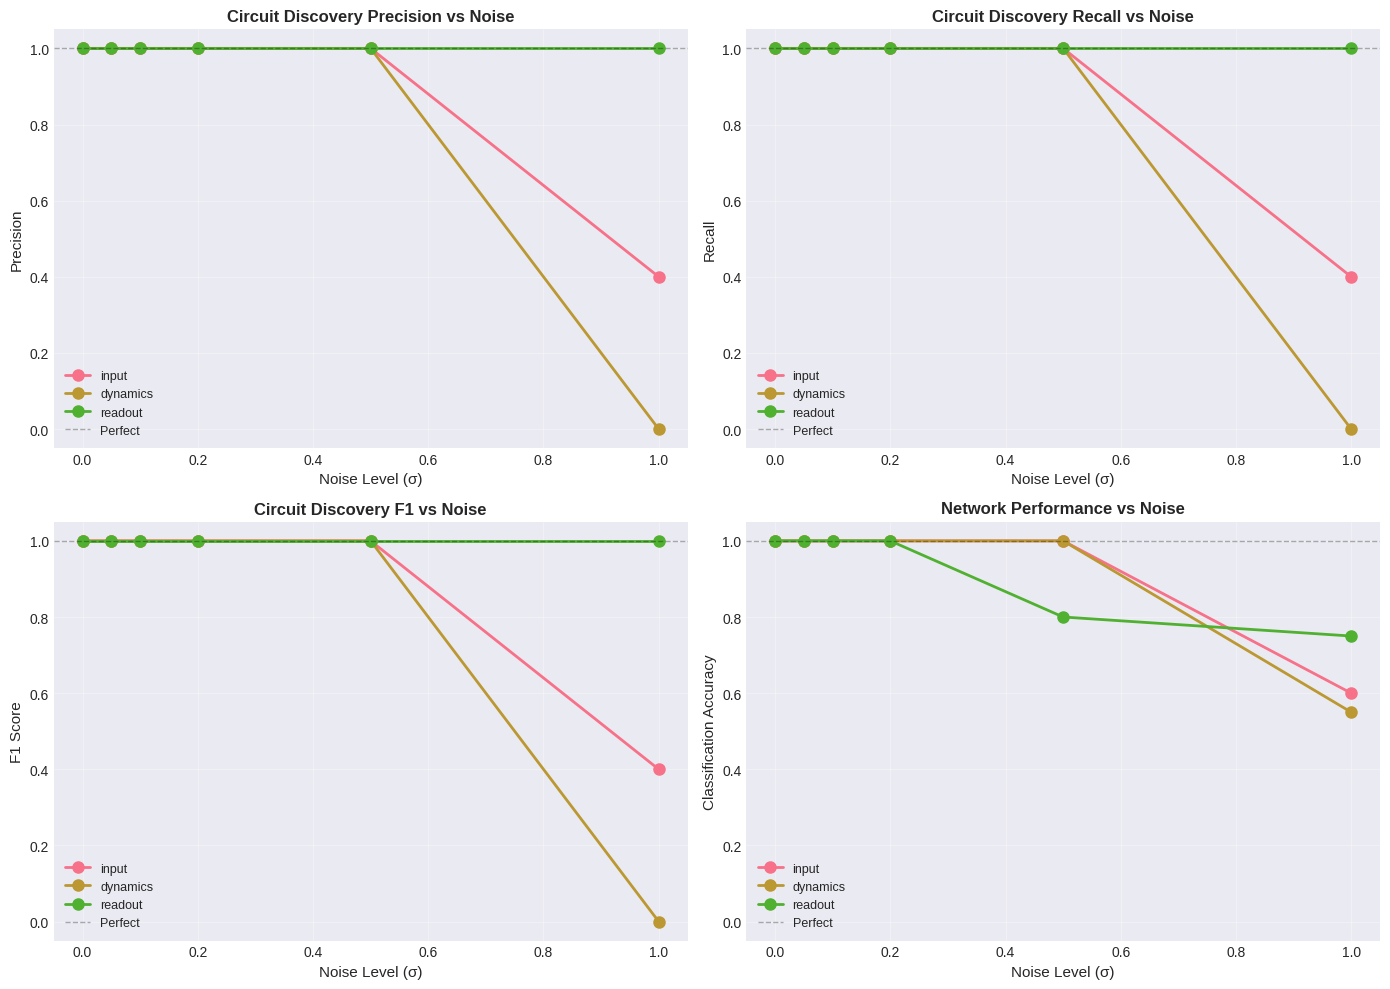


INTERPRETATION
Expected patterns:
  - Method should be robust to moderate noise (σ < 0.2)
  - Precision/recall should degrade gracefully, not catastrophically
  - Dynamics noise typically most disruptive (corrupts recurrent computation)
  - Readout noise least disruptive (only affects margin calculation)
  - When network accuracy drops, circuit discovery should also degrade


In [53]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Precision vs Noise
ax = axes[0, 0]
for noise_type in noise_types:
    ax.plot(noise_levels, results[noise_type]['precision'], 'o-', label=noise_type, linewidth=2, markersize=8)
ax.axhline(1.0, color='k', linestyle='--', linewidth=1, alpha=0.3, label='Perfect')
ax.set_xlabel('Noise Level (σ)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Circuit Discovery Precision vs Noise', fontsize=12, weight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# Plot 2: Recall vs Noise
ax = axes[0, 1]
for noise_type in noise_types:
    ax.plot(noise_levels, results[noise_type]['recall'], 'o-', label=noise_type, linewidth=2, markersize=8)
ax.axhline(1.0, color='k', linestyle='--', linewidth=1, alpha=0.3, label='Perfect')
ax.set_xlabel('Noise Level (σ)', fontsize=11)
ax.set_ylabel('Recall', fontsize=11)
ax.set_title('Circuit Discovery Recall vs Noise', fontsize=12, weight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# Plot 3: F1 vs Noise
ax = axes[1, 0]
for noise_type in noise_types:
    ax.plot(noise_levels, results[noise_type]['f1'], 'o-', label=noise_type, linewidth=2, markersize=8)
ax.axhline(1.0, color='k', linestyle='--', linewidth=1, alpha=0.3, label='Perfect')
ax.set_xlabel('Noise Level (σ)', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Circuit Discovery F1 vs Noise', fontsize=12, weight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# Plot 4: Network Accuracy vs Noise
ax = axes[1, 1]
for noise_type in noise_types:
    ax.plot(noise_levels, results[noise_type]['accuracy'], 'o-', label=noise_type, linewidth=2, markersize=8)
ax.axhline(1.0, color='k', linestyle='--', linewidth=1, alpha=0.3, label='Perfect')
ax.set_xlabel('Noise Level (σ)', fontsize=11)
ax.set_ylabel('Classification Accuracy', fontsize=11)
ax.set_title('Network Performance vs Noise', fontsize=12, weight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("Expected patterns:")
print("  - Method should be robust to moderate noise (σ < 0.2)")
print("  - Precision/recall should degrade gracefully, not catastrophically")
print("  - Dynamics noise typically most disruptive (corrupts recurrent computation)")
print("  - Readout noise least disruptive (only affects margin calculation)")
print("  - When network accuracy drops, circuit discovery should also degrade")